# Machine Learning Exam - Football Matches

# Stage 1: Problem Foundation
## Hypothesis

### Der er en relation mellem regnvejr og en kamps udspil
* Der scores flere mål i regnvejrskampe
* Der bliver uddelt flere kort i regnvejrskampe
* Der bliver generelt lavet flere fouls i regnvejrskampe
* Der bliver dømt flere frispark i regnvejrskampe

### Der er en relation mellem hjemmebanefordel og vundne kampe
* Man vinder oftere med hjemmebanefordel
* Hjemmebanehold får færre “fouls” stemt imod sig end udebanehold
* Udebanehold har flere kort pr. foul end hjemmebanehold

### Der er en relation mellem spilstrategi og vundne kampe
* Højere skud procent fører til flere mål

### Straffespark, Hjørnespark og Frispark påvirker fodboldkampe
* Mængden af kort et hold modtager har en korrelation til kampens resultat
* Mængden af hjørnespark har en korrelation til at vinde kampe
* Man vinder flere kampe, jo flere frispark et hold får dømt til deres fordel

# Stage 2: Data Preparation And Exploration
## Data Collection
### Import data
Her importerer vi vores raw data vi har fået. Dataen er fodbold-kamp data fra perioden 2025-02-04 -3026-03-13

In [1]:
import pandas as pd
rawdf = pd.read_csv("data/matchdataraw.csv")
cleaneddf = rawdf.copy()
cleaneddf.head()

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,...,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK
0,335,1699867,7458,11,9,4,0,1,2,65,...,15,1699867,"Nordsjælland - SønderjyskE, 0 - 2",2015-07-17 17:00:00.000,2015-07-17 15:00:00.000,Played,335,9493,4165479,1
1,335,1699867,7499,12,8,4,0,0,0,28,...,7,1699867,"Nordsjælland - SønderjyskE, 0 - 2",2015-07-17 17:00:00.000,2015-07-17 15:00:00.000,Played,335,9493,4165479,1
2,335,1699868,7456,5,14,2,0,1,2,19,...,18,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00.000,2015-07-18 13:00:00.000,Played,335,9493,4165479,1
3,335,1699868,7455,12,16,4,0,1,1,32,...,12,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00.000,2015-07-18 13:00:00.000,Played,335,9493,4165479,1
4,335,1699869,7460,14,10,4,0,1,0,38,...,8,1699869,"OB - Hobro, 3 - 0",2015-07-19 12:30:00.000,2015-07-19 10:30:00.000,Played,335,9493,4165479,1


## Cleaning
### Håndtering af NaN

In [2]:
cleaneddf.isnull().sum
cleaneddf.isna().sum()

COMPETITION_WYID           0
MATCH_WYID                 0
TEAM_WYID                  0
SHOTS                      0
FOULS                      0
CORNERS                    0
REDCARDS                   0
YELLOWCARDS                0
OFFSIDES                   0
DRIBBLES                   0
GOALS                      0
XGPERSHOT                  0
AVGDISTANCE                0
XG                         0
PROGRESSIVERUNS            0
TOUCHESINBOX               0
FOULSSUFFERED              0
SHOTSONTARGET              0
SHOTSBLOCKED               0
SHOTSOUTSIDEBOX            0
SHOTSOUTSIDEBOXONTARGET    0
SHOTSONPOST                0
SHOTSWIDE                  0
SHOTSFROMBOX               0
SHOTSFROMBOXONTARGET       0
FREEKICKS                  0
SHOTSFROMDANGERZONE        0
TOTALTHROWINS              0
LEFTTHROWINS               0
RIGHTTHROWINS              0
MATCH_WYID.1               0
MATCHLABEL                 0
DATE                       0
DATEUTC                    0
MATCHSTATUS   

### Håndtering af duplikeret rækker

In [3]:
cleaneddf.duplicated().sum()

np.int64(0)

### Håndtering af inkonsistente værdier (Danmark,DK)
  Vi fjerner "Expected goals per shot (XGPERSHOT)" pga. den er inkonsistent og der mangler data / forklaring på hvordan den laves korrekt

In [4]:
cleaneddf.drop(columns=["XGPERSHOT"], inplace=True)
print("XGPERSHOT i kolonner?", "XGPERSHOT" in cleaneddf.columns)

XGPERSHOT i kolonner? False


### Håndtering af outliers

Vi finder vores ekstreme outliers

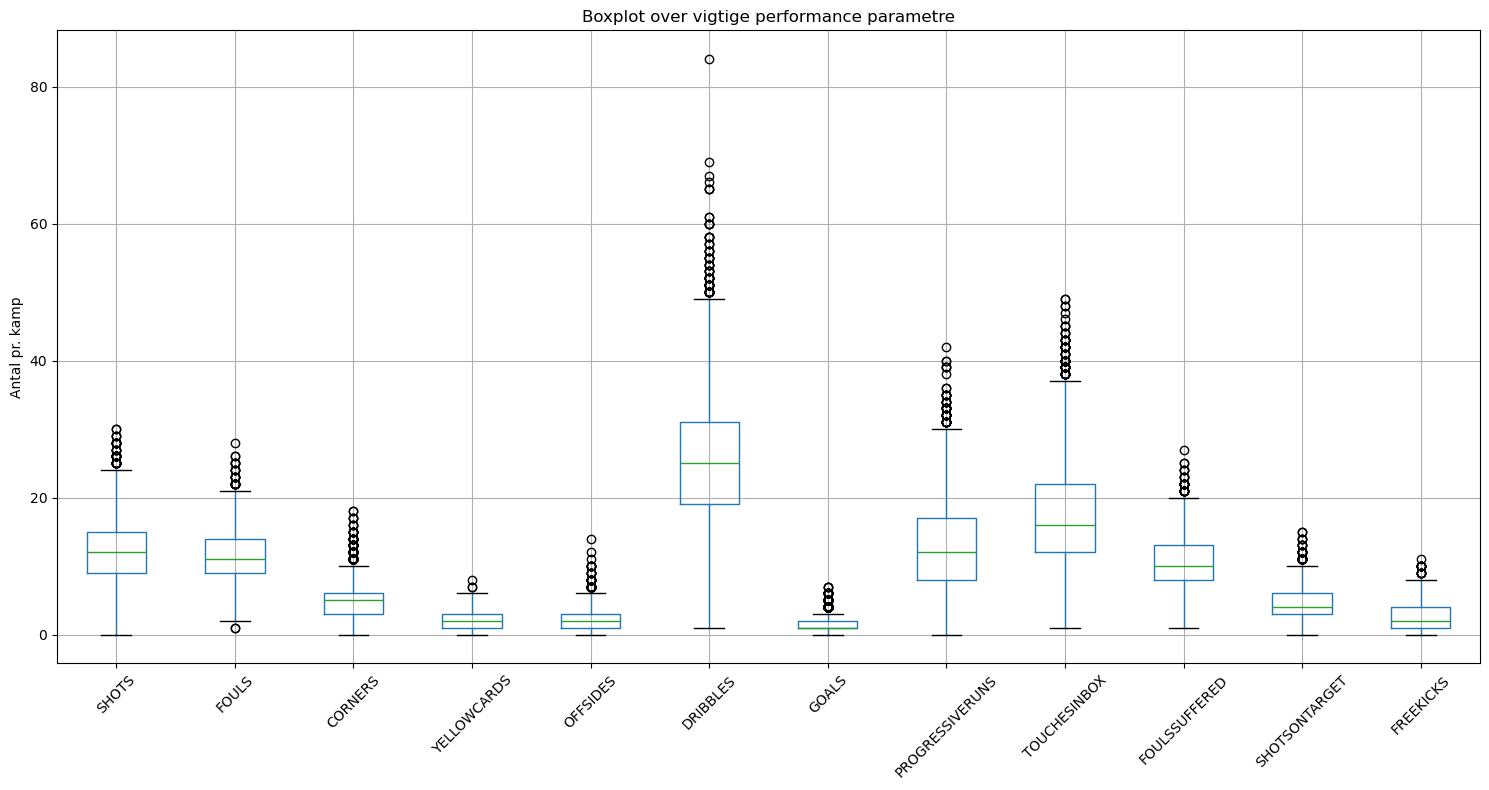

In [5]:
import matplotlib.pyplot as plt

performance_cols = [
    'SHOTS', 'FOULS', 'CORNERS', 'YELLOWCARDS', 'OFFSIDES', 
    'DRIBBLES', 'GOALS', 'PROGRESSIVERUNS', 'TOUCHESINBOX', 
    'FOULSSUFFERED', 'SHOTSONTARGET', 'FREEKICKS'
]

plt.figure(figsize=(15, 8))
cleaneddf[performance_cols].boxplot()
## Boxplot FØR outliers er fjernet
plt.xticks(rotation=45)
plt.title('Boxplot over vigtige performance parametre')
plt.ylabel('Antal pr. kamp')
plt.tight_layout()
plt.show()

In [6]:
# Vi finder hvilken outlier der er ekstrem i dribbles kategorien
outliers = cleaneddf[cleaneddf['DRIBBLES'] > 62]
display(outliers.head())

# Vi definerer en liste med alle de kamp-ID'er, vi vil ha fjernet
matches_to_remove = [1699867, 1699952, 2497370, 2720158, 2818322, 1699964]

# Vi sikrer at kolonnen er integer 
cleaneddf['MATCH_WYID'] = cleaneddf['MATCH_WYID'].astype(int)

# Vi fjerner listen
cleaneddf = cleaneddf[~cleaneddf['MATCH_WYID'].isin(matches_to_remove)]

# Vi dobbelt tjekker om de er blevet fjernet
outliers_check = cleaneddf[cleaneddf['DRIBBLES'] > 62]
display(outliers_check.head())

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,...,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK
0,335,1699867,7458,11,9,4,0,1,2,65,...,15,1699867,"Nordsjælland - SønderjyskE, 0 - 2",2015-07-17 17:00:00.000,2015-07-17 15:00:00.000,Played,335,9493,4165479,1
162,335,1699952,7457,10,9,6,0,1,1,67,...,14,1699952,"Randers - AGF, 4 - 1",2015-11-06 19:30:00.000,2015-11-06 18:30:00.000,Played,335,9493,4165479,15
182,335,1699964,7456,11,17,6,0,1,3,65,...,11,1699964,"Viborg - AGF, 1 - 0",2015-11-27 17:00:00.000,2015-11-27 16:00:00.000,Played,335,9493,4165479,17
183,335,1699964,7457,10,7,3,0,1,2,84,...,14,1699964,"Viborg - AGF, 1 - 0",2015-11-27 17:00:00.000,2015-11-27 16:00:00.000,Played,335,9493,4165479,17
1107,335,2497370,7461,16,7,8,0,0,2,65,...,26,2497370,"Silkeborg - Brøndby, 1 - 3",2017-11-26 18:00:00.000,2017-11-26 17:00:00.000,Played,335,181370,4405217,17


,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,...,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK


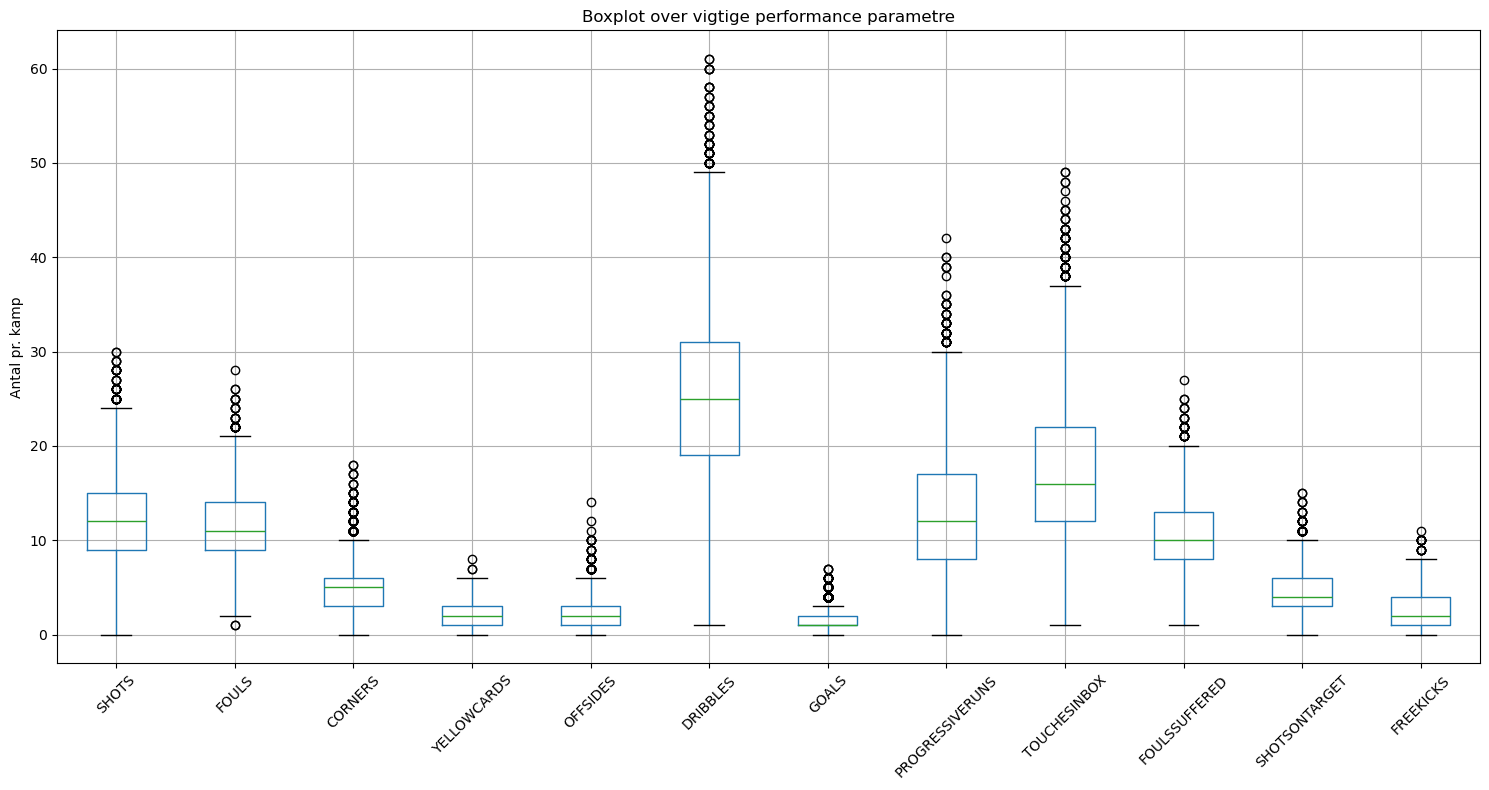

In [7]:
import matplotlib.pyplot as plt

performance_cols = [
    'SHOTS', 'FOULS', 'CORNERS', 'YELLOWCARDS', 'OFFSIDES', 
    'DRIBBLES', 'GOALS', 'PROGRESSIVERUNS', 'TOUCHESINBOX', 
    'FOULSSUFFERED', 'SHOTSONTARGET', 'FREEKICKS'
]

plt.figure(figsize=(15, 8))
cleaneddf[performance_cols].boxplot()
# boxplot efter outliers er fjernet
plt.xticks(rotation=45)
plt.title('Boxplot over vigtige performance parametre')
plt.ylabel('Antal pr. kamp')
plt.tight_layout()
plt.show()

## Structering
### Vejr data

## Transformation
### Kategoriske værdier til numeriske

In [8]:
cleaneddf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4528 entries, 2 to 4539
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   COMPETITION_WYID         4528 non-null   int64  
 1   MATCH_WYID               4528 non-null   int64  
 2   TEAM_WYID                4528 non-null   int64  
 3   SHOTS                    4528 non-null   int64  
 4   FOULS                    4528 non-null   int64  
 5   CORNERS                  4528 non-null   int64  
 6   REDCARDS                 4528 non-null   int64  
 7   YELLOWCARDS              4528 non-null   int64  
 8   OFFSIDES                 4528 non-null   int64  
 9   DRIBBLES                 4528 non-null   int64  
 10  GOALS                    4528 non-null   int64  
 11  AVGDISTANCE              4528 non-null   float64
 12  XG                       4528 non-null   float64
 13  PROGRESSIVERUNS          4528 non-null   int64  
 14  TOUCHESINBOX             4528

#### Vi vil gerne lave DATE og DATEUTC om til et datetime objekt

In [9]:
# Konverter DATE og DATEUTC til datetime-objekter
cleaneddf['DATE'] = pd.to_datetime(cleaneddf['DATE'])
cleaneddf['DATEUTC'] = pd.to_datetime(cleaneddf['DATEUTC'])

cleaneddf['weekday'] = cleaneddf['DATE'].dt.day_name() 

print(cleaneddf[['DATE', 'weekday']].head())
cleaneddf.info()

                 DATE   weekday
2 2015-07-18 15:00:00  Saturday
3 2015-07-18 15:00:00  Saturday
4 2015-07-19 12:30:00    Sunday
5 2015-07-19 12:30:00    Sunday
6 2015-07-19 17:00:00    Sunday
<class 'pandas.core.frame.DataFrame'>
Index: 4528 entries, 2 to 4539
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   COMPETITION_WYID         4528 non-null   int64         
 1   MATCH_WYID               4528 non-null   int64         
 2   TEAM_WYID                4528 non-null   int64         
 3   SHOTS                    4528 non-null   int64         
 4   FOULS                    4528 non-null   int64         
 5   CORNERS                  4528 non-null   int64         
 6   REDCARDS                 4528 non-null   int64         
 7   YELLOWCARDS              4528 non-null   int64         
 8   OFFSIDES                 4528 non-null   int64         
 9   DRIBBLES                 4528 

## Categorization

### Kategori med holdnavn og Kategori med nedbør ud fra vejrdata (nedbør mm)


In [10]:
cleaneddf.head()

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,...,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK,weekday
2,335,1699868,7456,5,14,2,0,1,2,19,...,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday
3,335,1699868,7455,12,16,4,0,1,1,32,...,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday
4,335,1699869,7460,14,10,4,0,1,0,38,...,1699869,"OB - Hobro, 3 - 0",2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday
5,335,1699869,7510,14,10,2,0,2,2,29,...,1699869,"OB - Hobro, 3 - 0",2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday
6,335,1699871,7453,11,20,8,0,1,4,15,...,1699871,"AGF - Brøndby, 2 - 1",2015-07-19 17:00:00,2015-07-19 15:00:00,Played,335,9493,4165479,1,Sunday


In [11]:
import pandas as pd
import numpy as np

team_mapping = {
    7458: 'Nordsjælland', 7499: 'SønderjyskE', 7456: 'Viborg', 
    7455: 'Midtjylland', 7460: 'OB', 7510: 'Hobro', 
    7452: 'København', 7462: 'Randers', 7453: 'Brøndby', 
    7457: 'AGF', 7454: 'AaB', 7451: 'Esbjerg', 
    7484: 'Lyngby', 7461: 'Silkeborg', 7465: 'Horsens', 
    7566: 'FC Helsingør', 7488: 'Vendsyssel', 7473: 'Vejle', 
    7490: 'Hvidovre', 7469: 'Fredericia'
}

cleaneddf['TEAM_WYID'] = pd.to_numeric(cleaneddf['TEAM_WYID'], errors='coerce').fillna(0).astype(int)

cleaneddf['Hold'] = cleaneddf['TEAM_WYID'].map(team_mapping)

cleaneddf['Total Cards'] = pd.to_numeric(cleaneddf['REDCARDS'], errors='coerce').fillna(0) + \
                           pd.to_numeric(cleaneddf['YELLOWCARDS'], errors='coerce').fillna(0)


if 'MATCHLABEL' in cleaneddf.columns:
    matchlabel_data = cleaneddf.pop('MATCHLABEL')
    cleaneddf['MATCHLABEL'] = matchlabel_data

pd.set_option('display.max_columns', None)
cleaneddf.head()

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK,weekday,Hold,Total Cards,MATCHLABEL
2,335,1699868,7456,5,14,2,0,1,2,19,0,14.1,0.3439,7,7,16,1,0,0,0,0,4,5,1,10,3,31,13,18,1699868,2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday,Viborg,1,"Midtjylland - Viborg, 2 - 0"
3,335,1699868,7455,12,16,4,0,1,1,32,2,22.2,0.9293,9,13,14,3,1,7,2,0,8,5,1,7,4,21,9,12,1699868,2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday,Midtjylland,1,"Midtjylland - Viborg, 2 - 0"
4,335,1699869,7460,14,10,4,0,1,0,38,3,20.9,1.3590,11,16,8,8,3,6,2,0,3,8,6,0,4,18,10,8,1699869,2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday,OB,1,"OB - Hobro, 3 - 0"
5,335,1699869,7510,14,10,2,0,2,2,29,0,22.3,1.2890,3,12,9,9,2,8,6,1,2,6,3,1,3,27,14,13,1699869,2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday,Hobro,2,"OB - Hobro, 3 - 0"
6,335,1699871,7453,11,20,8,0,1,4,15,1,19.6,0.9837,2,19,10,2,5,4,2,0,4,7,0,4,4,24,13,11,1699871,2015-07-19 17:00:00,2015-07-19 15:00:00,Played,335,9493,4165479,1,Sunday,Brøndby,1,"AGF - Brøndby, 2 - 1"


## Total info
- Total Cards
- Total Shots
- Total Fouls
- Total Corners
- Total Red cards
- Total Yellow cards
- Total Off-side
- Total Dribbles
- Total Goals
- Total Progressive runs
- Total Free kicks
- Total Throw ins
- Total Rain (hvis vejrdata bliver implemeneteret)

Her samler vi kampene til en kamp. Så to rows bliver til en row der beskriver hele kampen

In [12]:
import pandas as pd
import numpy as np

cols_to_sum = {
    'SHOTS': 'Total Shots',
    'FOULS': 'Total Fouls',
    'CORNERS': 'Total Corners',
    'REDCARDS': 'Total Red cards',
    'YELLOWCARDS': 'Total Yellow cards',
    'OFFSIDES': 'Total Off-side',
    'DRIBBLES': 'Total Dribbles',
    'GOALS': 'Total Goals',
    'PROGRESSIVERUNS': 'Total Progressive runs',
    'FREEKICKS': 'Total Free kicks',
    'TOTALTHROWINS': 'Total Throw ins'
}


match_df = cleaneddf.groupby(['MATCH_WYID', 'MATCHLABEL']).agg({
    **{col: 'sum' for col in cols_to_sum.keys()}
}).reset_index()

match_df.rename(columns=cols_to_sum, inplace=True)

match_df['Total Cards'] = match_df['Total Red cards'] + match_df['Total Yellow cards']

pd.set_option('display.max_columns', None)
match_df.head()

,MATCH_WYID,MATCHLABEL,Total Shots,Total Fouls,Total Corners,Total Red cards,Total Yellow cards,Total Off-side,Total Dribbles,Total Goals,Total Progressive runs,Total Free kicks,Total Throw ins,Total Cards
0,1699868,"Midtjylland - Viborg, 2 - 0",17,30,6,0,2,3,51,2,16,17,52,2
1,1699869,"OB - Hobro, 3 - 0",28,20,6,0,3,2,67,3,14,1,45,3
2,1699870,"København - Randers, 3 - 0",20,29,6,0,3,2,73,3,12,3,51,3
3,1699871,"AGF - Brøndby, 2 - 1",21,30,11,0,3,6,30,3,4,6,38,3
4,1699872,"AaB - Esbjerg, 1 - 1",36,25,15,0,4,2,52,2,13,1,44,4


### Rettelse af enkelte grammatik-fejl

In [13]:
cleaneddf = cleaneddf.replace("SønderjyskE", "Sønderjyske")
match_df = match_df.replace("SønderjyskE", "Sønderjyske")

# Check om ændringen er gået igennem
print((cleaneddf == "SønderjyskE").any().any())
print((match_df == "SønderjyskE").any().any())

False
False


### Rettelse af MATCHLABEL til HOMETEAM, AWAYTEAM, HOMEGOAL, AWAYGOAL

In [14]:
# Split hold og score: 
match_df[['Teams', 'Score']] = match_df['MATCHLABEL'].str.rsplit(', ', n=1, expand=True)

In [15]:
# Split hjemmhold og udehold:
match_df[['Home Team', 'Away Team']] = match_df['Teams'].str.split(' - ', expand=True)

In [16]:
# Split scoreline i hjemmemål og udemål
match_df[['Home Goals', 'Away Goals']] = match_df['Score'].str.split('-', expand=True)


In [17]:
# Sørger for at mål kun er tal
match_df["Home Goals"] = match_df["Home Goals"].astype(str).str.extract(r'(\d+)').astype(int)
match_df["Away Goals"] = match_df["Away Goals"].astype(str).str.extract(r'(\d+)').astype(int)

In [18]:
# Check om ændringen er gået igennem
match_df[['Teams', 'Score','Home Team','Away Team','Home Goals','Away Goals']].head()

,Teams,Score,Home Team,Away Team,Home Goals,Away Goals
0,Midtjylland - Viborg,2 - 0,Midtjylland,Viborg,2,0
1,OB - Hobro,3 - 0,OB,Hobro,3,0
2,København - Randers,3 - 0,København,Randers,3,0
3,AGF - Brøndby,2 - 1,AGF,Brøndby,2,1
4,AaB - Esbjerg,1 - 1,AaB,Esbjerg,1,1


In [19]:
# Reorder df:
cols = [
    'MATCH_WYID','MATCHLABEL','Teams','Score','Home Team','Away Team','Home Goals','Away Goals',
    'Total Shots','Total Fouls','Total Corners','Total Red cards','Total Yellow cards',
    'Total Off-side','Total Dribbles','Total Goals','Total Progressive runs',
    'Total Free kicks','Total Throw ins','Total Cards'
]

match_df = match_df[cols]

In [20]:
match_df.head()

,MATCH_WYID,MATCHLABEL,Teams,Score,Home Team,Away Team,Home Goals,Away Goals,Total Shots,Total Fouls,Total Corners,Total Red cards,Total Yellow cards,Total Off-side,Total Dribbles,Total Goals,Total Progressive runs,Total Free kicks,Total Throw ins,Total Cards
0,1699868,"Midtjylland - Viborg, 2 - 0",Midtjylland - Viborg,2 - 0,Midtjylland,Viborg,2,0,17,30,6,0,2,3,51,2,16,17,52,2
1,1699869,"OB - Hobro, 3 - 0",OB - Hobro,3 - 0,OB,Hobro,3,0,28,20,6,0,3,2,67,3,14,1,45,3
2,1699870,"København - Randers, 3 - 0",København - Randers,3 - 0,København,Randers,3,0,20,29,6,0,3,2,73,3,12,3,51,3
3,1699871,"AGF - Brøndby, 2 - 1",AGF - Brøndby,2 - 1,AGF,Brøndby,2,1,21,30,11,0,3,6,30,3,4,6,38,3
4,1699872,"AaB - Esbjerg, 1 - 1",AaB - Esbjerg,1 - 1,AaB,Esbjerg,1,1,36,25,15,0,4,2,52,2,13,1,44,4


### Laver kategorien VENUE, så det er nemt at se hvor kampen spilles:

In [21]:
# Create venue column directly in cleaneddf

cleaneddf = cleaneddf.sort_values("MATCH_WYID")

cleaneddf["ROW"] = cleaneddf.groupby("MATCH_WYID").cumcount()

cleaneddf["VENUE"] = cleaneddf["ROW"].map({0: "Home", 1: "Away"})

## Validation
Data er valideret og cleaned. Ingen missing values eller nonsens værdier

### Vi har to dataframes

#### cleaneddf 
Her opstår der kampe hvor der er to rækker for hver ene kamp. Hver række er fra hvert hold der spillede i den ene kamp. Der er tilføjet en kolonne helt ude til højre, som fortæller hvilket hold rækken tilhøre

#### match_df
Her er de to rækker merged sammen i en, hvor hele rækken viser total value for hele kampen


# Stage 3: Data Modeling

## Vejranalyse

### Vejrhypoteser: Der er en relation mellem regnvejr og en kamps udspil
1. Der scores flere mål i regnvejrskampe
2. Der bliver uddelt flere kort i regnvejrskampe
3. Der bliver generelt lavet flere fouls i regnvejrskampe
4. Der bliver dømt flere frispark i regnvejrskampe

Vi bruger følgende modeller:

 - Boxplot
 - Heatmap
 - Confusion Matrix
 - Logistisk Regression

Dataen er allerede blevet renset i Stage 2, derfor bruger vi direkte:

match_df   -> match level data
match_df_vejr -> der laves en ny dataframe med match og vejr

In [22]:
# Importerer vejrdata-funktionen fra vores utility fil
# samt os-biblioteket til filhåndtering
from dmi_utils import hent_vejr
import os

In [23]:
# Kommune-ID mapping — hvert hjemmehold mappes til DMI's kommunenummer
# Kommunenummeret bruges til at hente vejrdata fra DMI's API
TEAM_MUNICIPALITY = {
    "København": "0101",
    "Brøndby": "0153",
    "Nordsjælland": "0217",
    "Lyngby": "0173",
    "FC Helsingør": "0217",
    "Hvidovre": "0167",
    "OB": "0461",
    "Esbjerg": "0561",
    "SønderjyskE": "0540",
    "Sønderjyske": "0540",
    "AaB": "0851",
    "Vendsyssel": "0813",
    "Hobro": "0846",
    "Midtjylland": "0657",
    "AGF": "0751",
    "Viborg": "0791",
    "Horsens": "0615",
    "Fredericia": "0607",
    "Vejle": "0630",
    "Randers": "0730",
    "Silkeborg": "0740"
}
# Lav én række per kamp med dato og matchlabel
dato_map = cleaneddf.groupby('MATCH_WYID').agg(
    DATE=('DATE', 'first'),
    MATCHLABEL=('MATCHLABEL', 'first')
).reset_index()
# Udtræk hjemmeholdet — første hold i MATCHLABEL er altid hjemmeholdet
dato_map['home_team'] = dato_map['MATCHLABEL'].str.split(',').str[0].str.split(' - ').str[0].str.strip()
# Map hjemmeholdet til DMI kommune-ID
dato_map['municipality_id'] = dato_map['home_team'].map(TEAM_MUNICIPALITY)
# Konverter dato til streng format til DMI API kald
dato_map['dato_str'] = dato_map['DATE'].dt.strftime('%Y-%m-%d')

# Tjek om alle hold har fået et kommune-ID — tom liste = ingen mangler
print("Hold uden mapping:", dato_map[dato_map['municipality_id'].isna()]['home_team'].unique())

# Byg liste af unikke dato+kommune kombinationer — undgår dobbelte API-kald
unikke = dato_map[dato_map['municipality_id'].notna()][['dato_str', 'municipality_id']].drop_duplicates().reset_index(drop=True)
print(f"Unikke dato+kommune kombinationer: {len(unikke)}")

Hold uden mapping: []
Unikke dato+kommune kombinationer: 2263


In [24]:
# Opret data-mappe hvis den ikke eksisterer
os.makedirs("data", exist_ok=True)

# Sti til cache-fil — hvis den eksisterer hentes data herfra i stedet for DMI
CACHE_PATH = "data/vejr_cache.csv"

# Hent vejrdata fra DMI — bruger cache hvis tilgængelig
vejr_df = hent_vejr(unikke, cache_path=CACHE_PATH)
vejr_df.head()

Cache fundet — loader fra data/vejr_cache.csv


,dato_str,municipality_id,nedbor_mm
0,2015-07-18,0657,8.0
1,2015-07-19,0461,0.2
2,2015-09-16,0101,0.0
3,2015-07-19,0751,0.1
4,2015-07-20,0851,4.7


In [25]:
# Lav en kopi af match_df så vi ikke ændrer i den originale
match_df_vejr = match_df.copy()

In [26]:
# Sikrer municipality_id har 4 cifre med foranstillet nul (fx 657 -> 0657)
# Nødvendigt fordi CSV gemmer tallene uden foranstillet nul
dato_map['municipality_id'] = dato_map['municipality_id'].astype(str).str.zfill(4)
vejr_df['municipality_id'] = vejr_df['municipality_id'].astype(str).str.zfill(4)

# Merge vejrdata ind i dato_map via dato og kommune
dato_map2 = dato_map[['MATCH_WYID', 'dato_str', 'municipality_id']].merge(
    vejr_df,
    on=['dato_str', 'municipality_id'],
    how='left'
)

# Merge nedbørsmængde ind i match_df_vejr via kamp-ID
match_df_vejr = match_df_vejr.merge(
    dato_map2[['MATCH_WYID', 'nedbor_mm']],
    on='MATCH_WYID',
    how='left'
)
# Opret Total Regn kolonne med nedbør i mm
match_df_vejr['Total Regn'] = match_df_vejr['nedbor_mm']
match_df_vejr['Regnede'] = match_df_vejr['Total Regn'].apply(lambda x: pd.notna(x) and x > 0)

# Opret binær kolonne — True hvis der faldt mere end 0 mm regn
match_df_vejr.drop(columns=['nedbor_mm'], inplace=True)

# Fjern den midlertidige nedbor_mm kolonne
print(match_df_vejr['Regnede'].value_counts(dropna=False))
print("Antal uden vejrdata:", match_df_vejr['Total Regn'].isna().sum())

Regnede
True     1290
False     974
Name: count, dtype: int64
Antal uden vejrdata: 0


In [27]:
# Descriptive statistics — sammenlign gennemsnit for alle hypotesevariabler
# opdelt på om det regnede eller ej
print(match_df_vejr.groupby('Regnede')[['Total Goals', 'Total Yellow cards', 'Total Red cards', 'Total Fouls', 'Total Free kicks']].mean().round(2))

         Total Goals  Total Yellow cards  Total Red cards  Total Fouls  \
Regnede                                                                  
False           2.81                3.69             0.15        22.37   
True            2.84                3.63             0.14        22.61   

         Total Free kicks  
Regnede                    
False                4.98  
True                 5.08  


### Hypotese 1: Der scores flere mål i regnvejrskampe

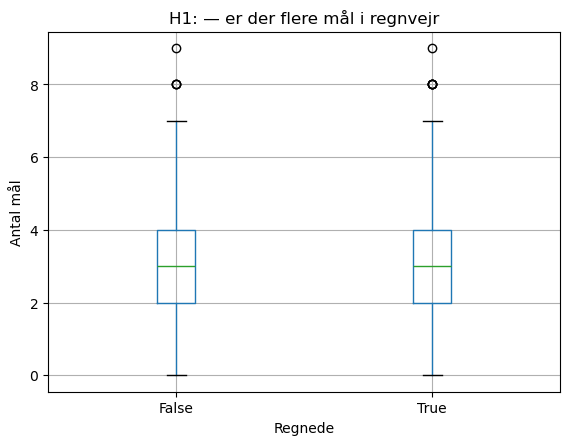

In [28]:
match_df_vejr.boxplot(column='Total Goals', by='Regnede')
plt.title('H1: — er der flere mål i regnvejr')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal mål')
plt.show()

In [29]:
!pip install scipy

In [30]:
# T-test — statistisk test om forskellen i mål mellem regn og tørvejr er signifikant
# p < 0.05 = signifikant forskel, p > 0.05 = ingen signifikant forskel
from scipy import stats

regn = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Goals']
torr = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Goals']

t, p = stats.ttest_ind(regn, torr)

print(f"Gennemsnit regn:     {regn.mean():.2f} mål")
print(f"Gennemsnit tørvejr:  {torr.mean():.2f} mål")
print(f"T-test p-værdi:      {p:.4f}")
print(f"Konklusion: {' SIGNIFIKANT forskel' if p < 0.05 else ' INGEN signifikant forskel'}")

Gennemsnit regn:     2.84 mål
Gennemsnit tørvejr:  2.81 mål
T-test p-værdi:      0.7139
Konklusion:  INGEN signifikant forskel


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Logistisk Regression — kan antal mål forudsige om det regnede?
# class_weight='balanced' bruges da der er flere regnkampe end tørvejrskampe
X = match_df_vejr[['Total Goals']].dropna()
y = match_df_vejr.loc[X.index, 'Regnede'].astype(int)

# 80% træning, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

print(classification_report(y_test, lr.predict(X_test)))
print(f"Koefficient for mål: {lr.coef_[0][0]:.4f}")

              precision    recall  f1-score   support

           0       0.36      0.44      0.40       180
           1       0.57      0.49      0.53       273

    accuracy                           0.47       453
   macro avg       0.47      0.47      0.46       453
weighted avg       0.49      0.47      0.48       453

Koefficient for mål: 0.0269


#### Konklusion — H1: Flere mål i regnvejr end tørvejr?

Gennemsnittet for mål i regnvejr var 2.84 mod 2.81 i tørvejr. T-testen gav en p-værdi på 0.7139, hvilket er langt over grænsen på 0.05. Den logistiske regression opnåede en accuracy på 0.47 med en koefficient på 0.0269 — tæt på nul hvilket indikerer ingen sammenhæng.

**Hypotesen afkræftes** — regn har ingen signifikant effekt på antal mål.

---

### Hypotese 2: Der bliver uddelt flere kort i regnvejrskampe

In [32]:
print(match_df_vejr.groupby('Regnede')[['Total Yellow cards', 'Total Red cards']].mean().round(2))

         Total Yellow cards  Total Red cards
Regnede                                     
False                  3.69             0.15
True                   3.63             0.14


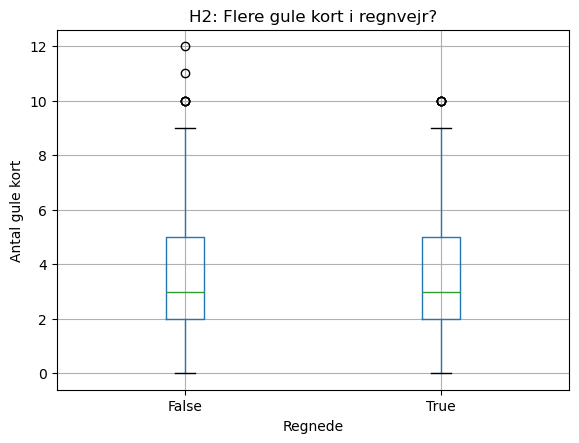

In [33]:
match_df_vejr.boxplot(column='Total Yellow cards', by='Regnede')
plt.title('H2: Flere gule kort i regnvejr?')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal gule kort')
plt.show()

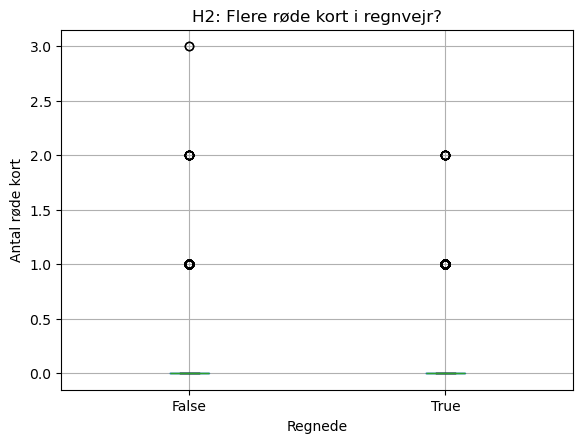

In [34]:
match_df_vejr.boxplot(column='Total Red cards', by='Regnede')
plt.title('H2: Flere røde kort i regnvejr?')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal røde kort')
plt.show()

In [35]:
# T-test for gule og røde kort separat
# Tester om forskellen i kort er statistisk signifikant
regn_gule = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Yellow cards']
torr_gule = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Yellow cards']

t, p_gule = stats.ttest_ind(regn_gule, torr_gule)

regn_rode = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Red cards']
torr_rode = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Red cards']

t, p_rode = stats.ttest_ind(regn_rode, torr_rode)

print(f"Gule kort — regn: {regn_gule.mean():.2f}  tørvejr: {torr_gule.mean():.2f}  p={p_gule:.4f} → {' SIGNIFIKANT' if p_gule < 0.05 else ' IKKE SIGNIFIKANT'}")
print(f"Røde kort — regn: {regn_rode.mean():.2f}  tørvejr: {torr_rode.mean():.2f}  p={p_rode:.4f} → {' SIGNIFIKANT' if p_rode < 0.05 else ' IKKE SIGNIFIKANT'}")

Gule kort — regn: 3.63  tørvejr: 3.69  p=0.4220 →  IKKE SIGNIFIKANT
Røde kort — regn: 0.14  tørvejr: 0.15  p=0.5603 →  IKKE SIGNIFIKANT


In [36]:
X = match_df_vejr[['Total Yellow cards', 'Total Red cards']].dropna()
y = match_df_vejr.loc[X.index, 'Regnede'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

print(classification_report(y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.38      0.86      0.53       180
           1       0.44      0.07      0.13       273

    accuracy                           0.39       453
   macro avg       0.41      0.47      0.33       453
weighted avg       0.42      0.39      0.29       453



#### Konklusion — H2: Flere kort i regnvejr end tørvejr?

Gennemsnittet for gule kort var 3.63 i regnvejr mod 3.69 i tørvejr med en p-værdi på 0.4220. For røde kort var gennemsnittet 0.14 i regnvejr mod 0.15 i tørvejr med en p-værdi på 0.5603. Den logistiske regression opnåede en accuracy på 0.39.

**Hypotesen afkræftes** — hverken gule eller røde kort påvirkes af regn.

---

### Hypotese 3: Der bliver generelt lavet flere fouls i regnvejrskampe


In [37]:
print(match_df_vejr.groupby('Regnede')[['Total Fouls']].mean().round(2))

         Total Fouls
Regnede             
False          22.37
True           22.61


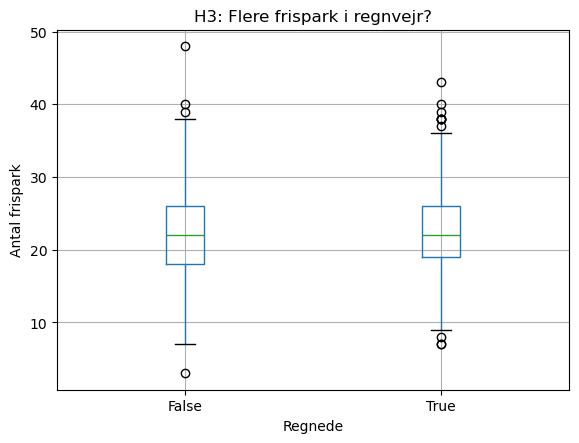

In [38]:
match_df_vejr.boxplot(column='Total Fouls', by='Regnede')
plt.title('H3: Flere frispark i regnvejr?')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal frispark')
plt.show()

In [39]:
regn_fouls = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Fouls']
torr_fouls = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Fouls']

t, p_fouls = stats.ttest_ind(regn_fouls, torr_fouls)

print(f"Frispark — regn: {regn_fouls.mean():.2f}  tørvejr: {torr_fouls.mean():.2f}  p={p_fouls:.4f} → {' SIGNIFIKANT' if p_fouls < 0.05 else ' IKKE SIGNIFIKANT'}")

Frispark — regn: 22.61  tørvejr: 22.37  p=0.3022 →  IKKE SIGNIFIKANT


In [40]:
X = match_df_vejr[['Total Fouls']].dropna()
y = match_df_vejr.loc[X.index, 'Regnede'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

print(classification_report(y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.41      0.52      0.46       180
           1       0.62      0.51      0.56       273

    accuracy                           0.51       453
   macro avg       0.51      0.51      0.51       453
weighted avg       0.54      0.51      0.52       453



#### Konklusion — H3: Flere fouls i regnvejr end tørvejr?

Gennemsnittet for fouls i regnvejr var 22.61 mod 22.37 i tørvejr. T-testen gav en p-værdi på 0.3022, hvilket er over grænsen på 0.05, og den logistiske regression opnåede en accuracy på 0.51.

**Hypotesen afkræftes** — regn har ingen signifikant effekt på antal fouls.

---

### Hypotese 4: Der bliver dømt flere frispark i regnvejrskampe


In [41]:
print(match_df_vejr.groupby('Regnede')[['Total Free kicks']].mean().round(2))

         Total Free kicks
Regnede                  
False                4.98
True                 5.08


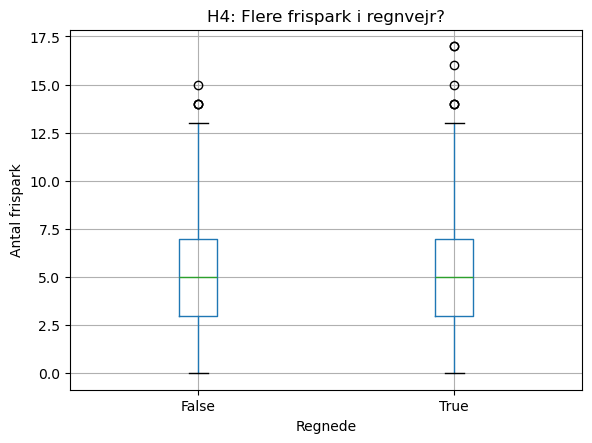

In [42]:
match_df_vejr.boxplot(column='Total Free kicks', by='Regnede')
plt.title('H4: Flere frispark i regnvejr?')
plt.suptitle('')
plt.xlabel('Regnede')
plt.ylabel('Antal frispark')
plt.show()

In [43]:
regn_frispark = match_df_vejr[match_df_vejr['Regnede'] == True]['Total Free kicks']
torr_frispark = match_df_vejr[match_df_vejr['Regnede'] == False]['Total Free kicks']

t, p_frispark = stats.ttest_ind(regn_frispark, torr_frispark)

print(f"Frispark — regn: {regn_frispark.mean():.2f}  tørvejr: {torr_frispark.mean():.2f}  p={p_frispark:.4f} → {' SIGNIFIKANT' if p_frispark < 0.05 else ' IKKE SIGNIFIKANT'}")

Frispark — regn: 5.08  tørvejr: 4.98  p=0.3441 →  IKKE SIGNIFIKANT


In [44]:
X = match_df_vejr[['Total Free kicks']].dropna()
y = match_df_vejr.loc[X.index, 'Regnede'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

print(classification_report(y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.40      0.61      0.49       180
           1       0.61      0.41      0.49       273

    accuracy                           0.49       453
   macro avg       0.51      0.51      0.49       453
weighted avg       0.53      0.49      0.49       453



#### Konklusion — H4: Flere frispark i regnvejr end tørvejr?

Gennemsnittet for frispark i regnvejr var 5.08 mod 4.98 i tørvejr. T-testen gav en p-værdi på 0.3441, hvilket er over grænsen på 0.05. Den logistiske regression opnåede en accuracy på 0.49.

**Hypotesen afkræftes** — regn har ingen signifikant effekt på antal frispark.

---

### Confusion Matrix for logistisk regression

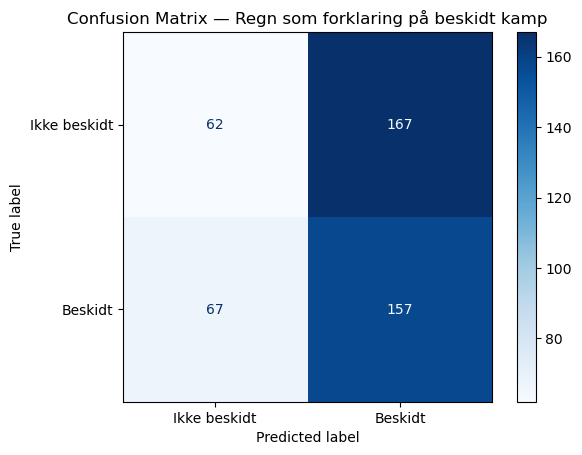

Accuracy: 0.48344370860927155
              precision    recall  f1-score   support

           0       0.48      0.27      0.35       229
           1       0.48      0.70      0.57       224

    accuracy                           0.48       453
   macro avg       0.48      0.49      0.46       453
weighted avg       0.48      0.48      0.46       453



In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Beregn en samlet beskidthedsværdi per kamp baseret på fouls, kort og frispark
# Fouls vægtes 0.5, gule kort 2, røde kort 4, frispark 1
# Kampe over medianen klassificeres som "beskidte kampe"
# Tester om regn alene kan forudsige om en kamp er beskidt

# Beskidthedsværdi
match_df_vejr['Beskidthedsværdi'] = (
    match_df_vejr['Total Fouls'] * 0.5 +
    match_df_vejr['Total Yellow cards'] * 2 +
    match_df_vejr['Total Red cards'] * 4 +
    match_df_vejr['Total Free kicks'] 
)

# Binær er den over eller under medianen
graense = match_df_vejr['Beskidthedsværdi'].median()
match_df_vejr['BeskidtKamp'] = (match_df_vejr['Beskidthedsværdi'] > graense).astype(int)

# X = kun regn - kan vi forudsige noget
X = match_df_vejr[['Total Regn']].fillna(0)
y = match_df_vejr['BeskidtKamp']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Træn logistisk regression med balanceret vægtning
# class_weight='balanced' kompenserer for ubalance mellem beskidte og ikke-beskidte kampe
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

# Forudsig om kampene i testdatasættet er beskidte eller ej
y_pred = lr.predict(X_test)

# Confusion matrix viser fordelingen af korrekte og forkerte forudsigelser
# Række = faktisk værdi, Kolonne = forudsagt værdi
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ikke beskidt', 'Beskidt']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Regn som forklaring på beskidt kamp')
plt.show()

# Accuracy = andel korrekt forudsagte kampe ud af alle kampe
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#### **Konklusion på modellen**
* Modellen præsterer kun omkring 45–50 % accuracy, hvilket er tæt på tilfældig gætning i et binært klassifikationsproblem. Det viser, at regn alene ikke giver modellen nok information til pålideligt at kunne afgøre, om en kamp bliver beskidt eller ej. Selvom modellen i nogle tilfælde rammer rigtigt, er den samlede præcision for lav til, at regn kan betragtes som en stærk forklaringsfaktor. På den baggrund tyder analysen på, at regn ikke kan bruges som en pålidelig indikator for kampens beskidthed.

---

In [46]:
team_df = cleaneddf.copy()
match_df = match_df.copy()

### KLYNGEDANNELSE (CLUSTERING) MED VEJRDATA OG VISUALISERING VIA PCA

Integration fuldført: 2580 regnvejrskampe identificeret.


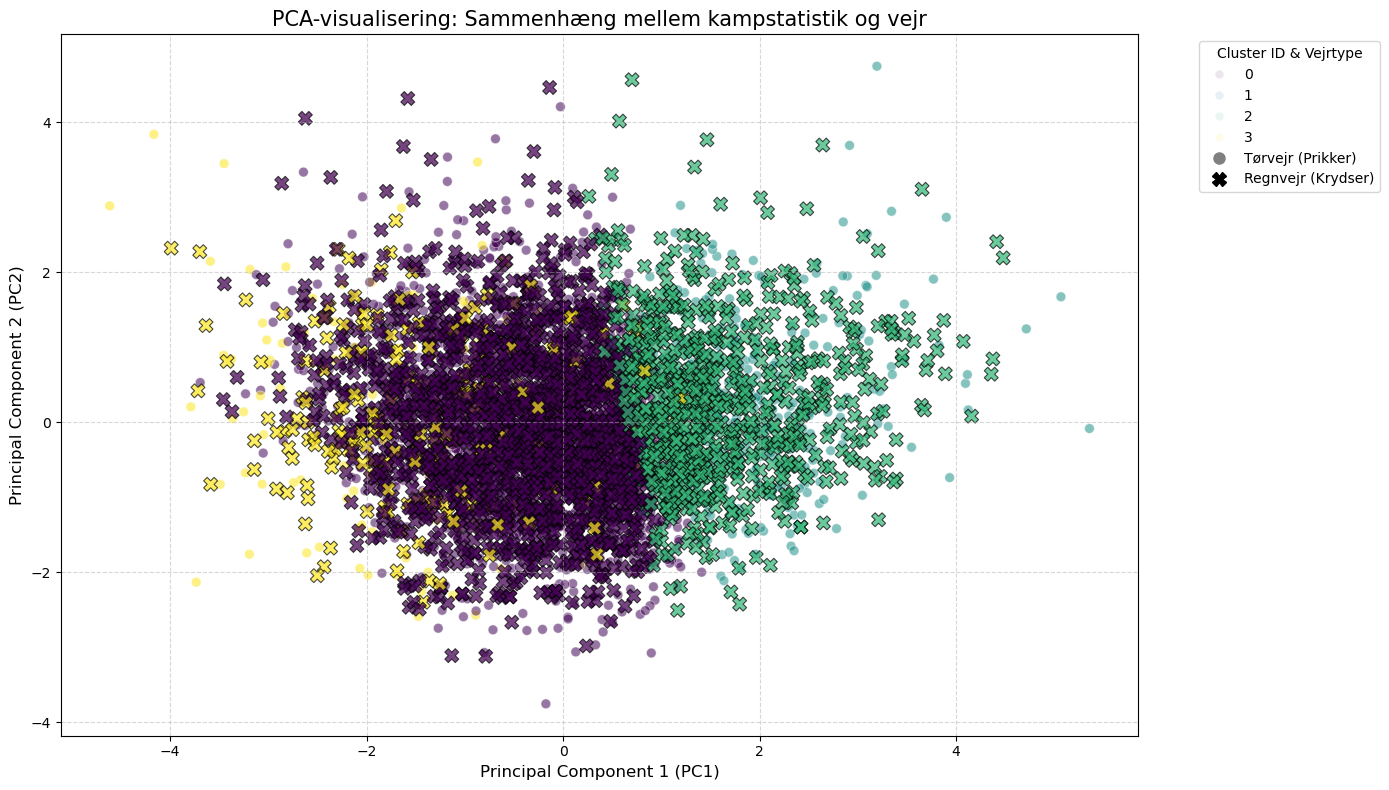


Statistisk oversigt over de dannede clusters:
             SHOTS      FOULS   CORNERS  YELLOWCARDS  REDCARDS     GOALS  \
Cluster                                                                    
0        10.126667  11.970303  4.072121     1.998788  0.000000  1.089091   
1        10.672188  11.563147  4.253278     1.956522  0.000000  1.189786   
2        16.946799   9.687106  7.368801     1.247971  0.000902  2.275023   
3        10.031250  11.571875  4.062500     2.365625  1.040625  1.118750   

          Regnede  
Cluster            
0        1.000000  
1        0.000000  
2        0.675383  
3        0.565625  


In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# KMeans clustering med vejrdata integreret
# Formål: Undersøg om regnvejr skaber naturlige grupperinger i kampdata
# PCA reducerer dimensioner til 2 for at muliggøre visualisering

# Datapræparation & Integration af Vejrdata
if 'match_df_vejr' in locals():
    cols_to_drop = [c for c in ['Regnede', 'Regnede_x', 'Regnede_y'] if c in team_df.columns]
    team_df = team_df.drop(columns=cols_to_drop)
    team_df = team_df.merge(match_df_vejr[['MATCH_WYID', 'Regnede']], on='MATCH_WYID', how='left')
    team_df['Regnede'] = team_df['Regnede'].apply(lambda x: 1 if x is True or x == 1 else 0)

print(f"Integration fuldført: {team_df['Regnede'].sum()} regnvejrskampe identificeret.")

# Feature Selection & Skalering
features = ['SHOTS', 'FOULS', 'CORNERS', 'YELLOWCARDS', 'REDCARDS', 'GOALS', 'Regnede']
df_analysis = team_df[features].copy().dropna()


scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_analysis)

# Unsupervised Learning: KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_analysis['Cluster'] = kmeans.fit_predict(scaled_features)

# Dimensionsreduktion: PCA 
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)
df_analysis['PC1'] = pca_components[:, 0]
df_analysis['PC2'] = pca_components[:, 1]

# --- 5. Professionel Visualisering (RETTET: Alle clusters inkluderes i legend) ---
plt.figure(figsize=(14, 8))

# 1. Vi tegner først alle punkter for at generere en komplet farve-legende
scatter = sns.scatterplot(data=df_analysis, x='PC1', y='PC2', hue='Cluster', 
                          palette='viridis', alpha=0.1) # Meget gennemsigtig baggrund

# 2. For tørvejr: Gør dem lidt tydeligere (alpha=0.5 i stedet for 0.3)
sns.scatterplot(data=df_analysis[df_analysis['Regnede'] == 0], 
                x='PC1', y='PC2', hue='Cluster', 
                palette='viridis', alpha=0.5, marker='o', s=50, legend=False)

# 3. For regnvejr: Gør dem lidt mindre (s=100) og lidt gennemsigtige (alpha=0.7)
sns.scatterplot(data=df_analysis[df_analysis['Regnede'] == 1], 
                x='PC1', y='PC2', hue='Cluster', 
                palette='viridis', alpha=0.7, marker='X', s=100, 
                edgecolor='black', legend=False)

# 4. Vi laver manuelle ikoner til vejr-forklaringen
dry_circle = mlines.Line2D([], [], color='gray', marker='o', linestyle='None',
                          markersize=8, label='Tørvejr (Prikker)')
rain_cross = mlines.Line2D([], [], color='black', marker='X', linestyle='None',
                          markersize=10, label='Regnvejr (Krydser)')

# 5. Saml det hele i én legende
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles=handles + [dry_circle, rain_cross], 
           title='Cluster ID & Vejrtype', 
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('PCA-visualisering: Sammenhæng mellem kampstatistik og vejr', fontsize=15)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Cluster Karakteristik
print("\nStatistisk oversigt over de dannede clusters:")
print(df_analysis.groupby('Cluster')[features].mean())

In [48]:
# Se gennemsnit
print("Gennemsnit pr. cluster:")
print(df_analysis.groupby('Cluster')[['SHOTS', 'FOULS', 'YELLOWCARDS', 'GOALS', 'Regnede']].mean())

Gennemsnit pr. cluster:
             SHOTS      FOULS  YELLOWCARDS     GOALS   Regnede
Cluster                                                       
0        10.126667  11.970303     1.998788  1.089091  1.000000
1        10.672188  11.563147     1.956522  1.189786  0.000000
2        16.946799   9.687106     1.247971  2.275023  0.675383
3        10.031250  11.571875     2.365625  1.118750  0.565625


#### Hvordan læser vi dette?
Når vi kigger på tallene kan vi se noget ret så interessant: Regnede (nedbør) er faktisk blevet den dominerende faktor for clusternes opdeling. 

Cluster 2 har præcis 0.00 i regn (100% tørvejr)
Cluster 3 har præcis 1.00 i regn (100% regnver)
Cluster 0 & 1 er blandingsgrupper, men med meget høje værdier for skud, især cluster 0

Man kan kalde cluster 0 for "Målfesten", pga højest antal skud og flest mål
- Dette er de kampe hvor der bliver angrebet meget

Cluster 1 kan man kalde for de "Hårde kampe", med flest gule kort (2.36) og mange fouls, få mål og få skud. Man kan antage at det er kampe der har fokus på overlevelse og tætte dueller frem for et clean angrebsspil.

Cluster 2 er tørvejrs-standard, og cluster 3 er regnvejs-standard. 

#### **Konklusion på klyngedannelse med vejrdata**
Ved at anvende PCA (Principal Component Analysis) har vi visualiseret, hvordan kampsituationer grupperer sig. Vores analyse viser, at mens faktorer som skud og mål definerer de mest ekstreme kampe (Cluster 0), så fungerer nedbør som en tydelig skillelinje i dataen.

Som det ses i PCA-plottet, skaber regnvejr (X-markørerne) deres egne clusters, men statistisk set minder 'regnvejrs-standardkampe' (Cluster 3) meget om 'tørvejrs-standardkampe' (Cluster 2). Dette indikerer, at selvom algoritmen kan kende forskel på vejret, så ændrer regnen ikke fundamentalt på holdenes evne til at producere skud og mål i de gennemsnitlige kampe.

### Heatmap

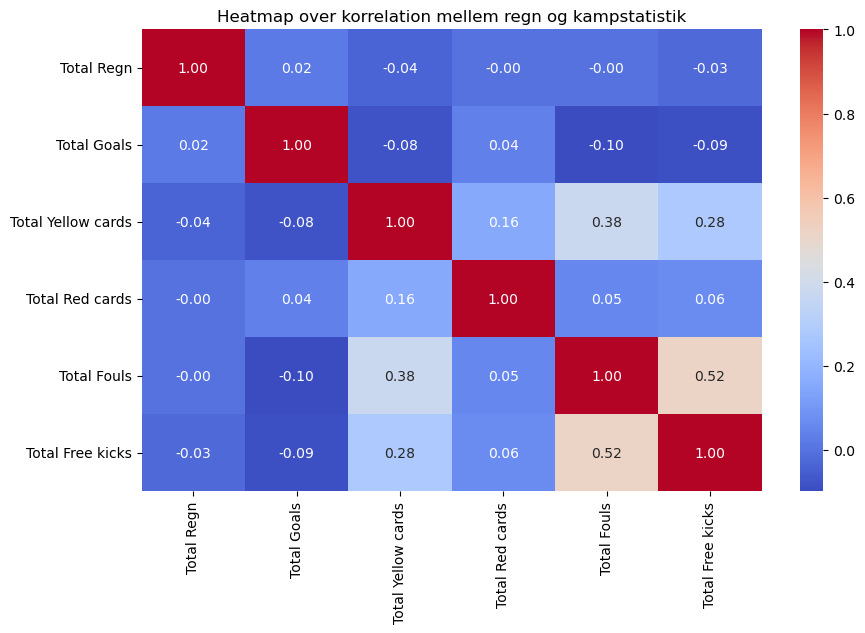

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = match_df_vejr[['Total Regn', 'Total Goals', 'Total Yellow cards', 'Total Red cards', 'Total Fouls', 'Total Free kicks']].copy()

corr = heatmap_df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap over korrelation mellem regn og kampstatistik')
plt.show()

**Det kan her ses via heatmappet at der på ingen måde er sammenhæng mellem regn og kort/fouls**

In [50]:
match_df_vejr.head()

,MATCH_WYID,MATCHLABEL,Teams,Score,Home Team,Away Team,Home Goals,Away Goals,Total Shots,Total Fouls,Total Corners,Total Red cards,Total Yellow cards,Total Off-side,Total Dribbles,Total Goals,Total Progressive runs,Total Free kicks,Total Throw ins,Total Cards,Total Regn,Regnede,Beskidthedsværdi,BeskidtKamp
0,1699868,"Midtjylland - Viborg, 2 - 0",Midtjylland - Viborg,2 - 0,Midtjylland,Viborg,2,0,17,30,6,0,2,3,51,2,16,17,52,2,8.0,True,36.0,1
1,1699869,"OB - Hobro, 3 - 0",OB - Hobro,3 - 0,OB,Hobro,3,0,28,20,6,0,3,2,67,3,14,1,45,3,0.2,True,17.0,0
2,1699870,"København - Randers, 3 - 0",København - Randers,3 - 0,København,Randers,3,0,20,29,6,0,3,2,73,3,12,3,51,3,0.0,False,23.5,0
3,1699871,"AGF - Brøndby, 2 - 1",AGF - Brøndby,2 - 1,AGF,Brøndby,2,1,21,30,11,0,3,6,30,3,4,6,38,3,0.1,True,27.0,1
4,1699872,"AaB - Esbjerg, 1 - 1",AaB - Esbjerg,1 - 1,AaB,Esbjerg,1,1,36,25,15,0,4,2,52,2,13,1,44,4,4.7,True,21.5,0


### **Samlet konklusion**

Resultaterne fra vejranalysen viser, at der ikke er en sammenhæng mellem regnvejr og kampenes udspil i Superligaen.

* T-testen viser ingen signifikante forskelle i mål, kort, fouls eller frispark mellem regnvejr og tørvejr, da alle p-værdier ligger langt over grænsen på 0.05.
* Heatmappet understøtter dette, da korrelationen mellem regn og de undersøgte kampvariable ligger meget tæt på 0.
* De logistiske modeller viser desuden, at regn ikke kan bruges til at forudsige kampstatistik, da accuracy ligger tæt på tilfældig gætning.
* Clustering-analysen viser, at mens regnvejr skaber en tydelig opdeling i dataen, minder regnvejrskampe statistisk set meget om tørvejrskampe.

Samlet set afkræfter analysen hypotesen om, at regnvejr påvirker kampens udspil i Superligaen.

---

## Hjemmebanefordel og spilstrategi

I denne sektion anvender vi machine learning til at teste vores hypoteser.

Hypotese 1: Der er en relation mellem hjemmebanefordel og vundne kampe
1. Man vinder oftere med hjemmebanefordel
2. Hjemmebanehold får færre “fouls” stemt imod sig end udebanehold
3. Udebanehold har flere kort pr foul end hjemmebanehold

Hypotese 2: Der er en relation mellem spilstrategi og vundne kampe
1. Højere skud procent fører til flere mål


Vi bruger følgende modeller:

 - Regression
 - Random Forest
 - Classification
 - Clustering (K-Means)

Dataen er allerede blevet renset i Stage 2, derfor bruger vi direkte:

cleaneddf  -> team level data
match_df   -> match level data

In [51]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, r2_score
import matplotlib.pyplot as plt

### Hypotese 1: Man vinder oftere med hjemmebanefordel

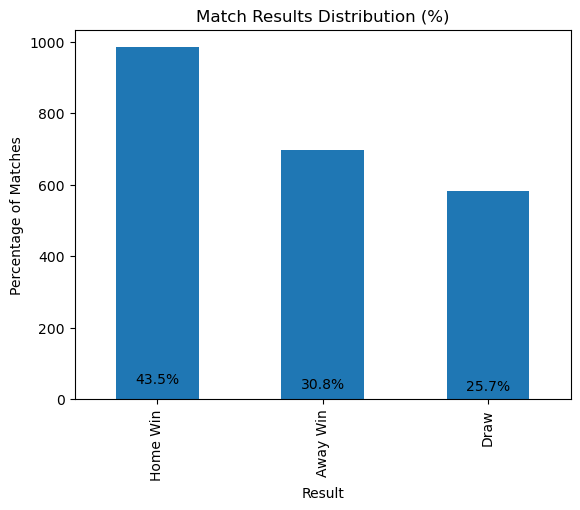

In [52]:
# Her laver vi en ny kolonne, som beskriver kampens resultat
# Hvis hjemmeholdet scorer flest mål, bliver resultatet "Home Win"
# Hvis udeholdet scorer flest mål, bliver resultatet "Away Win"
# Ellers bliver resultatet "Draw"
match_df["Result"] = np.select(
    [
        match_df["Home Goals"] > match_df["Away Goals"],
        match_df["Home Goals"] < match_df["Away Goals"]
    ],
    [
        "Home Win",
        "Away Win"
    ],
    default="Draw"
)

# Her tælles hvor mange gange hvert resultat forekommer
# og der laves et simpelt søjlediagram
match_df["Result"].value_counts().plot(kind="bar")

# Her omregnes resultaterne til procent
result_pct = match_df["Result"].value_counts(normalize=True) * 100

# Her laves et nyt søjlediagram, nu med procentfordelingen
ax = result_pct.plot(kind="bar")

plt.title("Match Results Distribution (%)")
plt.xlabel("Result")
plt.ylabel("Percentage of Matches")

# Her skrives procentværdien oven på hver søjle
for i, v in enumerate(result_pct):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.show()

#### Konklusion - Man vinder oftere med hjemmebanefordel
* Hypotesen om hjemmebanefordel er klart understøttet af vores data og kan bekræftes - da hjemmebaneholdet tager point i næsten 70% af kampene spillet, og vinder 43%

### Hypotese 2: Hjemmehold får færre fouls end udehold

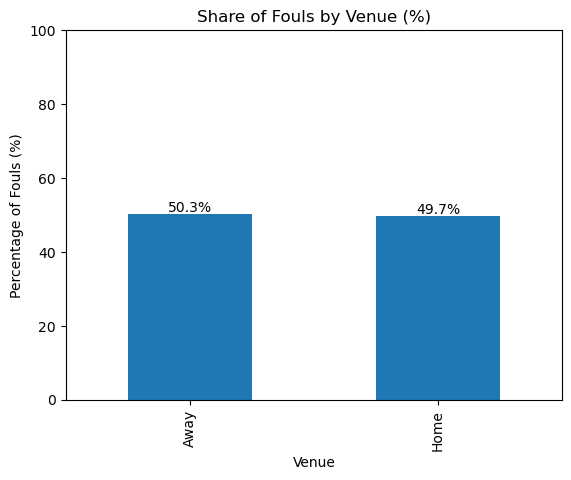

Average fouls home team: 11.194787985865725
Average fouls away team: 11.310512367491166


In [53]:
# Her summerer vi det samlede antal fouls for hjemme- og udehold
fouls_pct = cleaneddf.groupby("VENUE")["FOULS"].sum()

# Her omregner vi det til procent, så vi kan sammenligne andelen
fouls_pct = fouls_pct / fouls_pct.sum() * 100

# Her laver vi et søjlediagram over andelen af fouls på hjemme- og udebane
ax = fouls_pct.plot(kind="bar")

plt.title("Share of Fouls by Venue (%)")
plt.xlabel("Venue")
plt.ylabel("Percentage of Fouls (%)")

# Her skriver vi procentværdien oven på hver søjle
for i, v in enumerate(fouls_pct):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.ylim(0,100)
plt.show()

# Her finder vi gennemsnittet af fouls for hjemmehold
home_fouls = team_df[team_df["VENUE"] == "Home"]["FOULS"].mean()

# Her finder vi gennemsnittet af fouls for udehold
away_fouls = team_df[team_df["VENUE"] == "Away"]["FOULS"].mean()

# Her udskrives de to gennemsnit, så de kan sammenlignes direkte
print("Average fouls home team:", home_fouls)
print("Average fouls away team:", away_fouls)

#### Konklusion - Hjemmebanehold får færre fouls end udebanehold
* Hypotesen om færre fouls dømt mod hjemmebaneholdet kan her afvises, Idet det tydeligt fremgår, at "fouls" er ligeligt fordelt blandt hjemmebane- og udebanehold.

### Hypotese 3: Udebanehold har flere kort pr. foul end hjemmebanehold

In [54]:
# Samlet kortkolonne i cleaneddf:
cleaneddf["TOTAL_CARDS"] = cleaneddf["YELLOWCARDS"] + cleaneddf["REDCARDS"]

In [55]:
# Cards pr. foul:
cleaneddf["CARDS_PER_FOUL"] = cleaneddf["TOTAL_CARDS"] / cleaneddf["FOULS"]

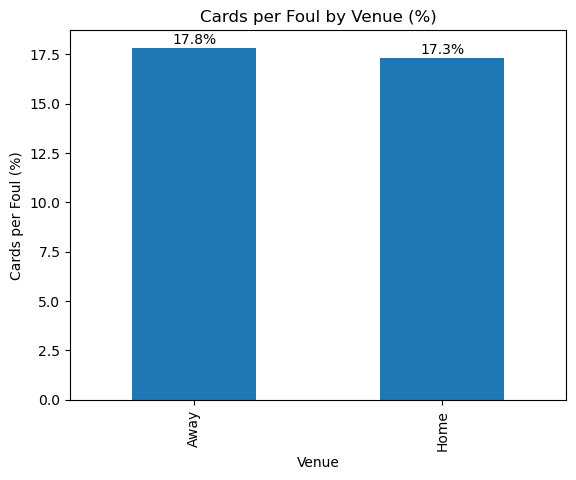

Cards per foul (home teams): 0.17310063523628172
Cards per foul (away teams): 0.1783081771875469


In [56]:
# Her laver vi først en samlet kort-kolonne som summen af gule og røde kort
cleaneddf["TOTAL_CARDS"] = cleaneddf["YELLOWCARDS"] + cleaneddf["REDCARDS"]

# Her beregner vi hvor mange kort der gives pr. foul
# Hvis FOULS er 0, erstattes det med 1 for at undgå division med 0
cleaneddf["CARDS_PER_FOUL"] = cleaneddf["TOTAL_CARDS"] / cleaneddf["FOULS"].replace(0,1)

# Her beregner vi gennemsnittet af cards per foul for hjemme- og udehold
# og ganger med 100 for at vise det i procent
cards_pct = cleaneddf.groupby("VENUE")["CARDS_PER_FOUL"].mean() * 100

# Her laver vi et søjlediagram for hjemmebane vs. udebane
ax = cards_pct.plot(kind="bar")

plt.title("Cards per Foul by Venue (%)")
plt.xlabel("Venue")
plt.ylabel("Cards per Foul (%)")

# Her skriver vi procentværdien oven på hver søjle
for i, v in enumerate(cards_pct):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center")

plt.show()

# Her finder vi den gennemsnitlige cards-per-foul-rate for hjemmehold
home_cards_rate = cleaneddf[cleaneddf["VENUE"] == "Home"]["CARDS_PER_FOUL"].mean()

# Her finder vi den gennemsnitlige cards-per-foul-rate for udehold
away_cards_rate = cleaneddf[cleaneddf["VENUE"] == "Away"]["CARDS_PER_FOUL"].mean()

# Her udskrives de to værdier, så de kan sammenlignes direkte
print("Cards per foul (home teams):", home_cards_rate)
print("Cards per foul (away teams):", away_cards_rate)

#### Konklusion - Udebanehold har færre kort pr. foul end hjemmebanehold
* Hypotesen om flere kort pr. foul til udebanehold kan dermed også afvises, da mængden af kort pr. forseelse er fuldstændig den samme for ude- såvel som hjemmebanehold.

### Hypotese 4 : Der er en relation mellem spilstrategi og vundne kampe - Højere skud procent fører til flere mål

In [57]:
# Vi laver først en ny feature: shot percentage.
team_df = cleaneddf.copy()
team_df["SHOT_PERCENTAGE"] = team_df["SHOTSONTARGET"] / team_df["SHOTS"].replace(0,1)

In [58]:
# Vi finder modstanderens mål i hver kamp
team_df = team_df.sort_values("MATCH_WYID")
team_df["OPP_GOALS"] = team_df.groupby("MATCH_WYID")["GOALS"].transform(lambda x: x.iloc[::-1].values)

#### Regression

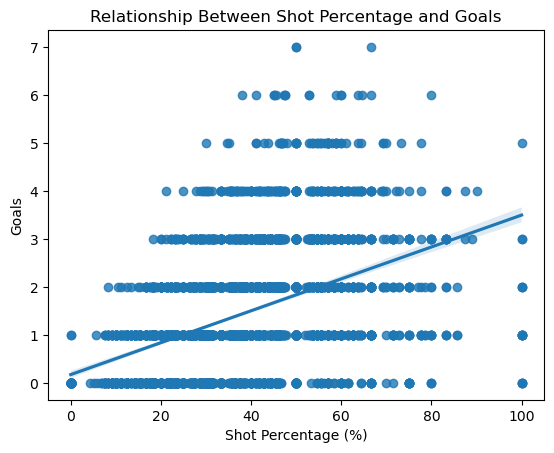

Regression R2 score: 0.3862847577212448
Coefficients: [2.98859073 0.01361742 0.59225715]
                            OLS Regression Results                            
Dep. Variable:                  GOALS   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     937.9
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        08:29:16   Log-Likelihood:                -6179.1
No. Observations:                4528   AIC:                         1.237e+04
Df Residuals:                    4524   BIC:                         1.239e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [59]:
# Vi undersøger her, om skudprocent, antal skud og xG kan forklare antal mål.
features = ["SHOT_PERCENTAGE", "SHOTS", "XG"]
target = "GOALS"

# X er inputvariablerne, og y er den variabel vi vil forudsige
X = team_df[features]
y = team_df[target]

# Data opdeles i træningsdata og testdata
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Her oprettes og trænes den lineære regressionsmodel
model = LinearRegression()
model.fit(X_train, y_train)

# Modellen laver forudsigelser på testdata
pred = model.predict(X_test)

import seaborn as sns

# Her laves et simpelt plot af sammenhængen mellem skudprocent og mål
sns.regplot(
    x=team_df["SHOT_PERCENTAGE"] * 100,
    y=team_df["GOALS"]
)

plt.xlabel("Shot Percentage (%)")
plt.ylabel("Goals")
plt.title("Relationship Between Shot Percentage and Goals")
plt.show()

# Her udskrives modellens R2-score og koefficienter
print("Regression R2 score:", r2_score(y_test, pred))
print("Coefficients:", model.coef_)

import statsmodels.api as sm

# Her bruges de samme features igen til en OLS-regression
X = team_df[["SHOT_PERCENTAGE", "SHOTS", "XG"]]
y = team_df["GOALS"]

# Vi tilføjer en konstant, så modellen også får et intercept
X = sm.add_constant(X)

# Her trænes OLS-modellen
model_sm = sm.OLS(y, X).fit()

# Her vises det fulde regressionsoutput med bl.a. p-værdier og koefficienter
print(model_sm.summary())

##### Regressionsmodel - Konklusion

*  Det kan her ses, at der er en sammenhæng mellem stigende antal mål ud fra mere akkurate skud.

* På OLS Regression Results kan p-value også aflæses, hvor den på shot percentage, shots og expected goals alle er under 0,05. Dette betyder at der er en overenstemmelse mellem en kamps resultat og disse faktorer


#### Random Forest

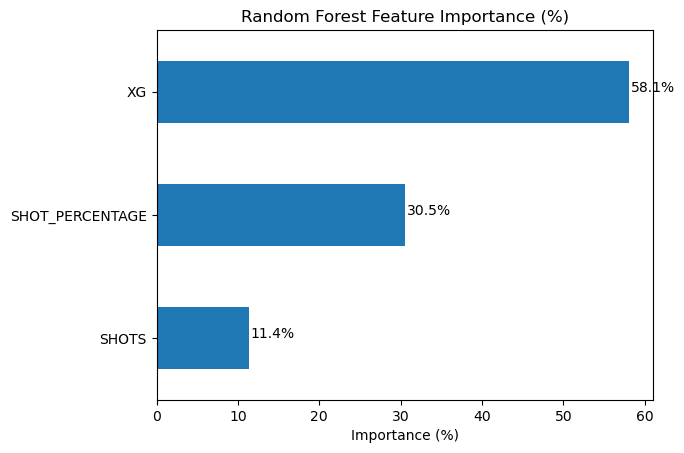

Random Forest R2 score: 0.3279443882961718


In [60]:
# Random Forest bruges her, fordi modellen kan finde mere komplekse
# sammenhænge mellem variablerne end en lineær model.

rf_model = RandomForestRegressor(random_state=42)

# Her trænes modellen på træningsdata
rf_model.fit(X_train, y_train)

# Her laver modellen forudsigelser på testdata
pred_rf = rf_model.predict(X_test)

# Her henter vi feature importance ud og gør dem til procent
importance = rf_model.feature_importances_ * 100

# Her kobles importance-værdierne sammen med feature-navnene
feature_importance = pd.Series(importance, index=features)

# Her laves et horisontalt søjlediagram over variablernes betydning
ax = feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance (%)")
plt.xlabel("Importance (%)")

# Her skrives procentværdien ud ved siden af hver søjle
for i, v in enumerate(feature_importance.sort_values()):
    ax.text(v + 0.2, i, f"{v:.1f}%")

plt.show()

# Her udskrives modellens R2-score, som viser hvor godt modellen forklarer variationen i y
print("Random Forest R2 score:", r2_score(y_test, pred_rf))


##### Random Forest - Konklusion
* Random Forest-modellen bruges til at identificere, hvilke variabler der bidrager mest til at forudsige antallet af mål. Analysen af feature importance viser, at skudprocent og expected goals (XG) er blandt de vigtigste faktorer for, hvor mange mål et hold scorer.

#### Classification
Her forsøger vi at forudsige om et hold vinder kampen.

In [61]:
# Vi sørger for, at vi kan bruge regn-data i team_df ved at merge på MATCH_WYID

regn_map = match_df_vejr[['MATCH_WYID', 'Regnede']].drop_duplicates()
team_df = team_df.merge(
    regn_map,
    on='MATCH_WYID',
    how='left'
)
team_df['Regnede'] = team_df['Regnede'].fillna(False).astype(int)

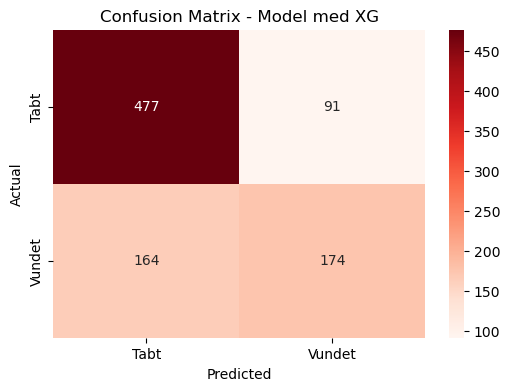

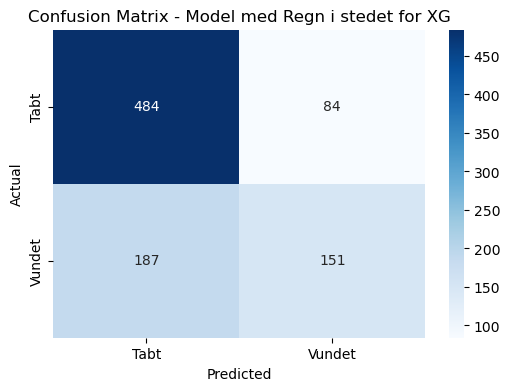

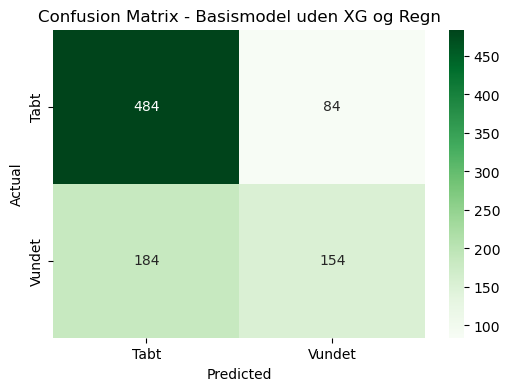

Accuracy med XG: 0.7185430463576159
              precision    recall  f1-score   support

           0       0.74      0.84      0.79       568
           1       0.66      0.51      0.58       338

    accuracy                           0.72       906
   macro avg       0.70      0.68      0.68       906
weighted avg       0.71      0.72      0.71       906

Accuracy med Regn: 0.7008830022075055
              precision    recall  f1-score   support

           0       0.72      0.85      0.78       568
           1       0.64      0.45      0.53       338

    accuracy                           0.70       906
   macro avg       0.68      0.65      0.65       906
weighted avg       0.69      0.70      0.69       906

Accuracy uden XG og Regn: 0.7041942604856513
              precision    recall  f1-score   support

           0       0.72      0.85      0.78       568
           1       0.65      0.46      0.53       338

    accuracy                           0.70       906
   macro 

In [62]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Vi laver en ny target-kolonne:
team_df["WIN"] = (team_df["GOALS"] > team_df["OPP_GOALS"]).astype(int)

# y er det, modellerne skal forudsige
y = team_df["WIN"]

# Model A bruger XG som feature
features_xg = [
    "SHOT_PERCENTAGE",
    "SHOTSONTARGET",
    "SHOTS",
    "XG",
    "FOULS",
    "CORNERS",
    "FREEKICKS"
]

# Model B bruger regn i stedet for XG
features_rain = [
    "SHOT_PERCENTAGE",
    "SHOTSONTARGET",
    "SHOTS",
    "Regnede",
    "FOULS",
    "CORNERS",
    "FREEKICKS"
]

# Model C er en basismodel uden både XG og regn
features_base = [
    "SHOT_PERCENTAGE",
    "SHOTSONTARGET",
    "SHOTS",
    "FOULS",
    "CORNERS",
    "FREEKICKS"
]

# Her udvælges input-variablerne til de tre modeller
X_a = team_df[features_xg]
X_b = team_df[features_rain]
X_c = team_df[features_base]

# Samme train/test split bruges til alle modeller,
# så sammenligningen bliver fair
train_idx, test_idx = train_test_split(team_df.index, test_size=0.2, random_state=42)

X_train_a, X_test_a = X_a.loc[train_idx], X_a.loc[test_idx]
X_train_b, X_test_b = X_b.loc[train_idx], X_b.loc[test_idx]
X_train_c, X_test_c = X_c.loc[train_idx], X_c.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

# Her trænes model A, og den laver prediction på testdata
clf_a = LogisticRegression(max_iter=2000)
clf_a.fit(X_train_a, y_train)
pred_a = clf_a.predict(X_test_a)

# Her trænes model B, og den laver prediction på testdata
clf_b = LogisticRegression(max_iter=2000)
clf_b.fit(X_train_b, y_train)
pred_b = clf_b.predict(X_test_b)

# Her trænes model C, og den laver prediction på testdata
clf_c = LogisticRegression(max_iter=2000)
clf_c.fit(X_train_c, y_train)
pred_c = clf_c.predict(X_test_c)

# Her laves confusion matrix for hver model
cm_a = confusion_matrix(y_test, pred_a)
cm_b = confusion_matrix(y_test, pred_b)
cm_c = confusion_matrix(y_test, pred_c)

# Visualisering af model A (med XG)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_a, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Tabt", "Vundet"],
            yticklabels=["Tabt", "Vundet"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Model med XG")
plt.show()

# Visualisering af model B (med regn i stedet for XG)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Tabt", "Vundet"],
            yticklabels=["Tabt", "Vundet"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Model med Regn i stedet for XG")
plt.show()

# Visualisering af model C (basismodel)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_c, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Tabt", "Vundet"],
            yticklabels=["Tabt", "Vundet"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Basismodel uden XG og Regn")
plt.show()

# Her udskrives accuracy og classification report for alle tre modeller
print("Accuracy med XG:", accuracy_score(y_test, pred_a))
print(classification_report(y_test, pred_a))

print("Accuracy med Regn:", accuracy_score(y_test, pred_b))
print(classification_report(y_test, pred_b))

print("Accuracy uden XG og Regn:", accuracy_score(y_test, pred_c))
print(classification_report(y_test, pred_c))

##### Confusion Matrix - Konklusion

* Confusion matrixen viser fordelingen mellem korrekte og forkerte forudsigelser. Modellen klassificerer generelt nederlag bedre end sejre, men viser stadig en rimelig evne til at forudsige kampresultater.
* På trods af hypotesen, har vi valgt at tilføje regn som en faktor for at checke, om denne skulle have noget indflydelse på om en kamp er vundet eller tabt.
* Dette kan ud fra alle tre matrixer afkræftes, idet resultatet virker til kun at afhænge af shots, XG og shotpercentage.

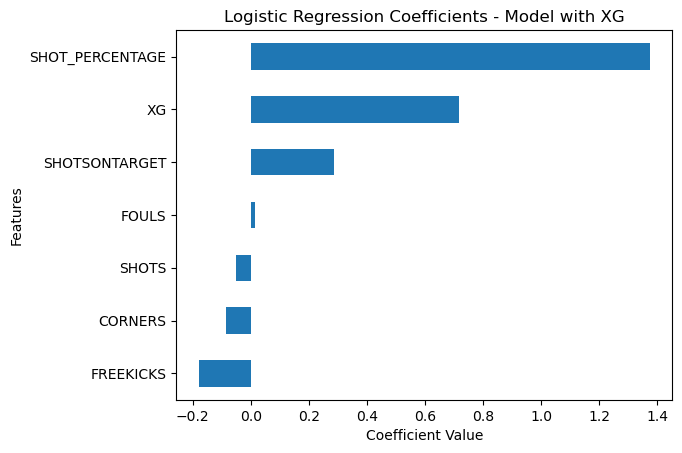

MODEL A - XG
Accuracy: 0.7185
F1-score: 0.5771
Precision: 0.6566
Recall: 0.5148



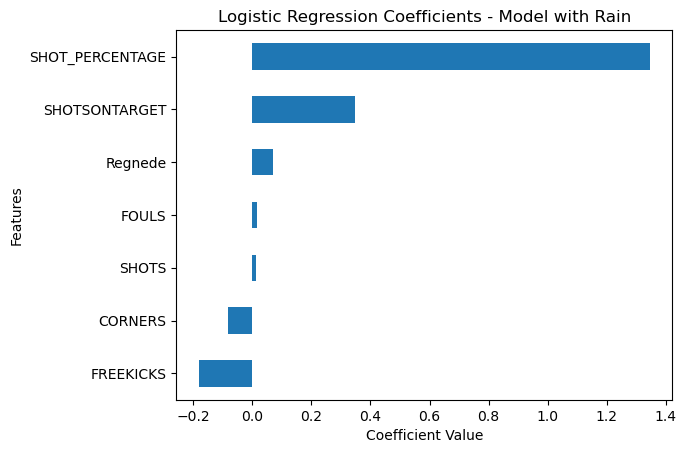

MODEL B - RAIN
Accuracy: 0.7009
F1-score: 0.5271
Precision: 0.6426
Recall: 0.4467



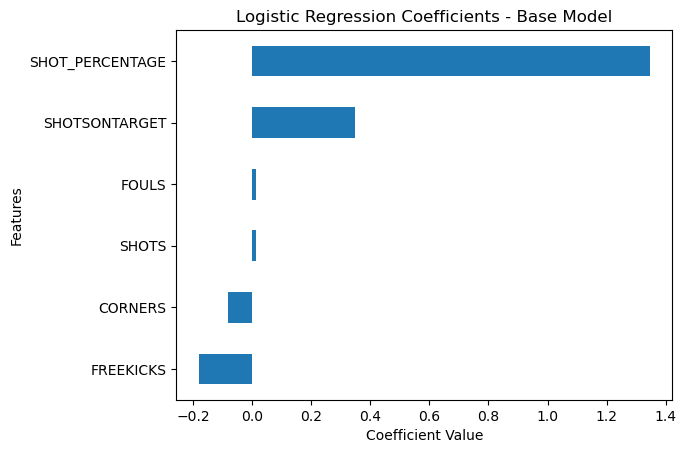

MODEL C - BASE
Accuracy: 0.7042
F1-score: 0.5347
Precision: 0.6471
Recall: 0.4556


In [63]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
# MODEL A: Logistic regression med XG

# Her henter vi modellens koefficienter ud og kobler dem til feature-navnene
coef_a = pd.Series(clf_a.coef_[0], index=features_xg)

# Her sorterer vi koefficienterne, så de bliver lettere at læse i plottet
coef_a = coef_a.sort_values()

# Her laver vi et horisontalt søjlediagram over koefficienterne
coef_a.plot(kind="barh")

# Titel
plt.title("Logistic Regression Coefficients - Model with XG")

# Tekst på x-aksen
plt.xlabel("Coefficient Value")

# Tekst på y-aksen
plt.ylabel("Features")

# Viser grafen
plt.show()

# Her beregner vi hvor god modellen er på testdata
acc_a = accuracy_score(y_test, pred_a)
f1_a = f1_score(y_test, pred_a)
precision_a = precision_score(y_test, pred_a)
recall_a = recall_score(y_test, pred_a)

# Her printer vi modelkvaliteten ud
print("MODEL A - XG")

# Hvor akkurat er modellen:
print("Accuracy:", round(acc_a, 4))

# Hvor god er modellen til at ramme og fange relevante cases
print("F1-score:", round(f1_a, 4))

# Hvor ofte har modellen ret
print("Precision:", round(precision_a, 4))

# Hvor meget overser modellen egentlig
print("Recall:", round(recall_a, 4))
print()


# MODEL B: Logistic regression med regn

coef_b = pd.Series(clf_b.coef_[0], index=features_rain)
coef_b = coef_b.sort_values()

coef_b.plot(kind="barh")
plt.title("Logistic Regression Coefficients - Model with Rain")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

acc_b = accuracy_score(y_test, pred_b)
f1_b = f1_score(y_test, pred_b)
precision_b = precision_score(y_test, pred_b)
recall_b = recall_score(y_test, pred_b)

print("MODEL B - RAIN")
print("Accuracy:", round(acc_b, 4))
print("F1-score:", round(f1_b, 4))
print("Precision:", round(precision_b, 4))
print("Recall:", round(recall_b, 4))
print()


# MODEL C: Basismodel uden XG og uden regn

coef_c = pd.Series(clf_c.coef_[0], index=features_base)
coef_c = coef_c.sort_values()

coef_c.plot(kind="barh")
plt.title("Logistic Regression Coefficients - Base Model")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

acc_c = accuracy_score(y_test, pred_c)
f1_c = f1_score(y_test, pred_c)
precision_c = precision_score(y_test, pred_c)
recall_c = recall_score(y_test, pred_c)

print("MODEL C - BASE")
print("Accuracy:", round(acc_c, 4))
print("F1-score:", round(f1_c, 4))
print("Precision:", round(precision_c, 4))
print("Recall:", round(recall_c, 4))

##### Logistisk regression - Konklusion
* Resultaterne fra Logistic Regression viser, at skudprocent og expected goals (XG) er de vigtigste faktorer for at forudsige, om et hold vinder en kamp. Modellen opnår en accuracy på ca. 65 %, hvilket indikerer en moderat god evne til at klassificere kampresultater baseret på kampstatistikker.
* Dog er modellerne generelt dårligere til at finde sejre, som det kan ses ud fra recall, f1 og precision, da disse i alle tilfælde er under 50%.
* Modellerne er altså gode til at gætte om en kamp er tabt, men knap så god til at gætte om en kamp er vundet.

#### Clustering

In [64]:
# Her grupperer vi hold efter deres spillestil.

cluster_features = [
    "SHOTS",
    "SHOTSONTARGET",
    "SHOT_PERCENTAGE",
    "XG",
    "FOULS",
    "CORNERS"
]

# Her trækker vi de relevante data ud fra den store tabel "team_df"
X_cluster = team_df[cluster_features]

# Klargører en "StandardScaler", da data har forskellige enheder så skal vi skalere dem til sammen niveau
scaler = StandardScaler()

# Omregner værdierne så de kan sammenlignes af algoritmen
X_scaled = scaler.fit_transform(X_cluster)

# Her definerer vi vores model. Vi beder den finde 3 grupper (n_clusters=3).
# random_state=42 sikrer sig at vi får det samme resultat hver gang vi kører koden.
kmeans = KMeans(n_clusters=3, random_state=42)

# Her "træner" vi modellen og lader den tildele hvert hold en gruppe(cluster)
team_df["Cluster"] = kmeans.fit_predict(X_scaled)

# Til sidst beregner vi gennemsnittet for hver gruppe, som gør det muligt at se om fx cluster 0 er offensive hold.
team_df.groupby("Cluster")[cluster_features + ["GOALS"]].mean()

,SHOTS,SHOTSONTARGET,SHOT_PERCENTAGE,XG,FOULS,CORNERS,GOALS
Cluster,,,,,,,
0,16.979457,6.577403,0.394516,2.280694,10.639765,6.892150,2.018342
1,9.907494,2.320258,0.237212,0.985316,11.644028,4.464871,0.729508
2,9.685655,4.814001,0.512748,1.206654,11.367193,3.660947,1.650652


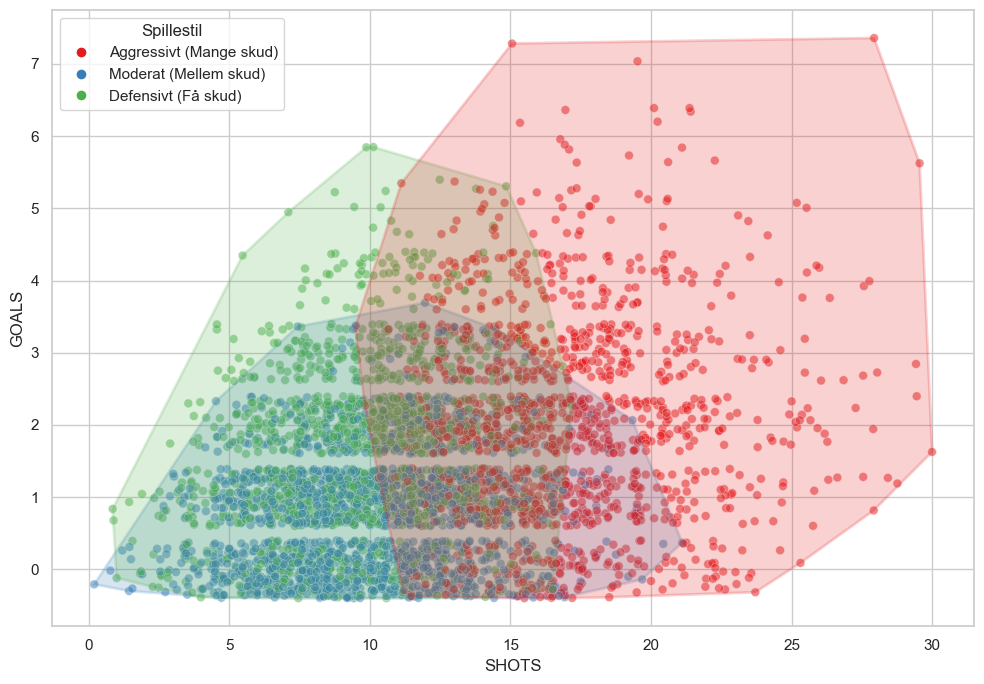

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import numpy as np

# Opsætning af grafens udseende (størrelse og det hvide gitter)
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Tilføjer "jitter" (tilfældig støj på tallene) som undgår at tallene er oveni hinanden.
team_df['SHOTS'] = team_df['SHOTS'] + np.random.uniform(-0.6, 0.6, len(team_df))
team_df['GOALS'] = team_df['GOALS'] + np.random.uniform(-0.4, 0.4, len(team_df))

# Her vælger vi faste farver til clusters
colors = {
    0: '#e41a1c',  # rød
    1: '#377eb8',  # blå
    2: '#4daf4a'   # grøn
}

# Tegner prikkerne (Scatterplot), og farves efter deres cluster ID
sns.scatterplot(
    data=team_df,
    x='SHOTS',
    y='GOALS',
    hue='Cluster',
    palette=colors,
    alpha=0.5,
    s=40
)

# Tegner convex hull rundt om hver cluster, forbinder yderpunkter som en elastik
for cluster_id in team_df['Cluster'].unique():
    points = team_df[team_df['Cluster'] == cluster_id][['SHOTS', 'GOALS']].values

    if len(points) >= 3:
        hull = ConvexHull(points)
        plt.fill(
            points[hull.vertices, 0],
            points[hull.vertices, 1],
            alpha=0.2,
            color=colors.get(cluster_id, 'gray'),
            edgecolor=colors.get(cluster_id, 'gray'),
            lw=2
        )

from matplotlib.lines import Line2D

# Vi sorterer grupperne efter gennemsnitligt antal skud, så vi kan kalde dem "Defensiv" eller "Aggresiv"
cards_avg = (
    team_df
    .groupby('Cluster')['SHOTS']
    .mean()
    .sort_values()
    .reset_index()
)

cluster_labels = {
    cards_avg.iloc[0]['Cluster']: 'Defensivt (Få skud)',
    cards_avg.iloc[1]['Cluster']: 'Moderat (Mellem skud)',
    cards_avg.iloc[2]['Cluster']: 'Aggressivt (Mange skud)'
}

# Vi bygger en manuel signaturforklaring (legend) med vores egne navne og farver
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=cluster_labels[c],
           markerfacecolor=colors[c],
           markersize=8)
    for c in sorted(colors.keys())
]

# Vi tilføjer en signaturforklaring og derefter viser vores graf
plt.legend(handles=legend_elements, title='Spillestil', loc='upper left')
plt.tight_layout()
plt.show()


* Overlap opstår fordi der kun visualiseres to variable, og fordi spillestile i praksis ikke er skarpt adskilt.

#### Konklusion - Der er en relation mellem spilstrategi og vundne kampe - Højere skud procent fører til flere mål
Resultaterne fra analysen viser, at der er en tydelig sammenhæng mellem spillestil og sandsynligheden for at vinde en kamp. 
* Regressionen viser en positiv relation mellem skudprocent, expected goals (XG) og antallet af mål, hvilket indikerer, at hold med mere effektive afslutninger scorer flere mål. 
* Random Forest-modellen understøtter dette ved at vise, at skudprocent og XG er blandt de vigtigste faktorer for at forudsige mål. 
* Logistic Regression-modellen viser desuden, at disse variabler også har en positiv indflydelse på sandsynligheden for at vinde en kamp. 
* Clustering-analysen identificerer forskellige spillestile blandt holdene, hvor mere offensive spillestile generelt er forbundet med flere mål. Samlet set understøtter analyserne hypotesen om, at spillestil har en betydning for, om et hold vinder en kamp.

---

## Disciplin og kampresultater

### Hypoteser: 
Straffespark, Hjørnespark og Frispark påvirker fodboldkampe¶
1. Mængden af kort et hold modtager har en korrelation til kampens resultat
2. Man vinder flere kampe, jo flere frispark et hold får dømt til deres fordel
3. Mængden af hjørnespark har en korrelation til at vinde kampe

Vi bruger følgende modeller:
 - Regression
 - Random Forest
 - Classification
 - Clustering (K-Means)

Dataen er allerede blevet renset i Stage 2, derfor bruger vi direkte:

cleaneddf  -> team level data
match_df   -> match level data

### Hypotese 1 & 2: 
- **Mængden af kort et hold modtager har en korrelation til kampens resultat**
- **Man vinder flere kampe, jo flere frispark et hold får dømt til deres fordel**

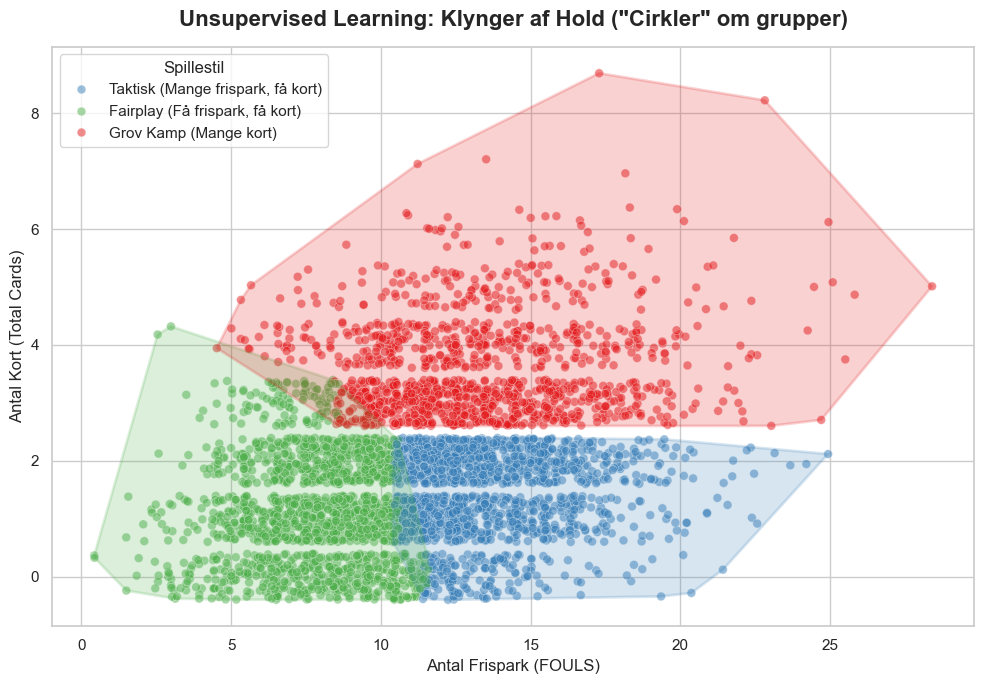

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull


### Klargøring af data

# Vi indlæser datasættet med kampdata
cardsdf = pd.read_csv('data/cleaneddf.csv')

# Vi skaber en samlet variabel for "Total Cards" ved at lægge gule og røde kort sammen.
if 'Total Cards' not in cardsdf.columns:
    cardsdf['Total Cards'] = cardsdf['YELLOWCARDS'] + cardsdf['REDCARDS']

# Vi udvælger de to faktorer, som algoritmen skal kigge på: "Kort" og "Frispark"
cardsdf_cluster = cardsdf[['Total Cards', 'FOULS']].copy()

# Dernæst fjerner vi rækker som har fejl, eller manglende data for at undgå koden går ned
cardsdf_cluster = cardsdf_cluster.dropna()


### Træning af vores maskine (Unsupervised ML)

# Standardisering: Eftersom frispark er højere tal end kort, skal vi "normalisere" dem, for at tydeliggøre at frispark ikke er vigtigere end kort.
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cardsdf_cluster)

# Vi definerer KMeans-modellen til at finde præcis 3 klynger/grupper
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Algoritmen analyserer mønstrene og tildeler hver kamp et gruppenummer (0,1,2)
cardsdf_cluster['Gruppe_Nummer'] = kmeans.fit_predict(data_scaled)

### Navngivning af vores nye grupperingerx

# Vi finder gennemsnittet for hver gruppe, for at vide hvad der kendetegner dem
cards_avg = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['Total Cards', 'FOULS']
)
cards_avg['Gruppe_Nummer'] = [0, 1, 2]

# Sorterer grupperne efter antal kort, så vi logisk kan give dem navne
cards_avg = cards_avg.sort_values(by=['Total Cards'])

# Her mapper vi de rå gruppenumre til forståelige titler
navne = {
    cards_avg.iloc[0]['Gruppe_Nummer']: 'Fairplay (Få frispark, få kort)',
    cards_avg.iloc[1]['Gruppe_Nummer']: 'Taktisk (Mange frispark, få kort)',
    cards_avg.iloc[2]['Gruppe_Nummer']: 'Grov Kamp (Mange kort)'
}

cardsdf_cluster['Spillestil'] = cardsdf_cluster['Gruppe_Nummer'].map(navne)


### Visualiering (Plotting)

plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Spreder prikkerne igen med lidt "Jitter"
# Da kort og frispark er hele tal ville de uden jitter ligge direkte oveni hinanden
cardsdf_cluster['FOULS_plot'] = cardsdf_cluster['FOULS'] + np.random.uniform(-0.6, 0.6, len(cardsdf_cluster))
cardsdf_cluster['Cards_plot'] = cardsdf_cluster['Total Cards'] + np.random.uniform(-0.4, 0.4, len(cardsdf_cluster))

# Vi definerer specifikke farver for klyngerne (Grøn = Fairplay, Blå = Taktisk, Rød = Grov Kamp)
farver = {
    'Fairplay (Få frispark, få kort)': '#4daf4a',
    'Taktisk (Mange frispark, få kort)': '#377eb8',
    'Grov Kamp (Mange kort)': '#e41a1c'
}

# Tegner prikkerne (Scatterplottet)
sns.scatterplot(
    data=cardsdf_cluster,
    x='FOULS_plot',
    y='Cards_plot',
    hue='Spillestil',
    palette=farver,
    alpha=0.5,
    s=40
)

# Convex Hull - tegner de farvede områder omkring hver gruppe
for gruppe_navn in cardsdf_cluster['Spillestil'].unique():
    prikker = cardsdf_cluster[cardsdf_cluster['Spillestil'] == gruppe_navn][['FOULS_plot', 'Cards_plot']].values
    
    if len(prikker) >= 3:
        hull = ConvexHull(prikker) # Finder de yderste punkter i klyngen
        plt.fill(
            prikker[hull.vertices, 0],
            prikker[hull.vertices, 1],
            alpha=0.2,
            color=farver[gruppe_navn],
            edgecolor=farver[gruppe_navn],
            lw=2
        )

# Tilføjer titler og tekst på akserne til plottet
plt.title('Unsupervised Learning: Klynger af Hold ("Cirkler" om grupper)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Antal Frispark (FOULS)', fontsize=12)
plt.ylabel('Antal Kort (Total Cards)', fontsize=12)
plt.legend(title='Spillestil', loc='upper left')

plt.tight_layout()
plt.show()

/var/folders/qm/ybqngckn3l18t10bwlsg57hm0000gn/T/ipykernel_52142/3855753558.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_udfald = cardsdf.groupby('MATCH_WYID', group_keys=False).apply(find_udfald).dropna(subset=['Resultat'])


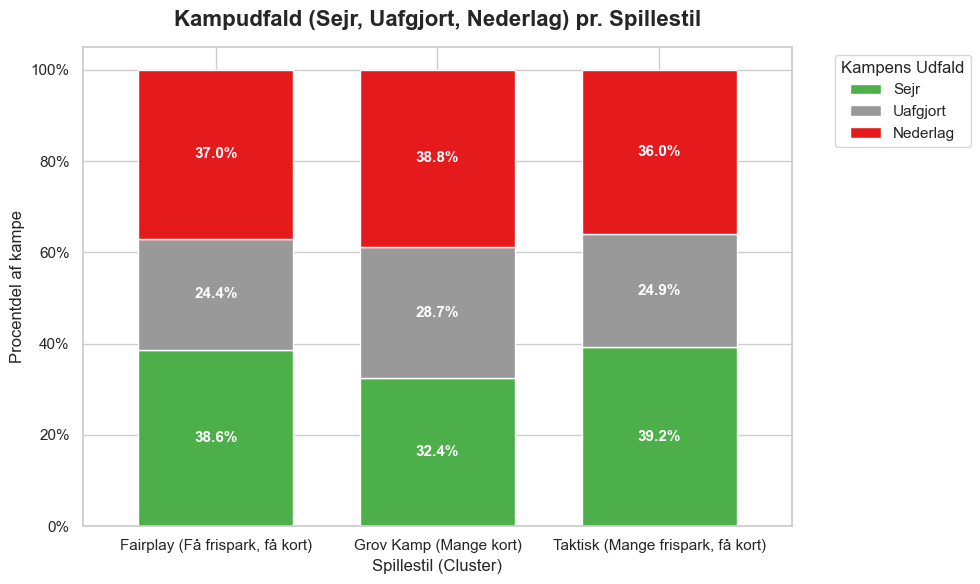

In [67]:
import matplotlib.ticker as mtick


### Besvarelse af hypotesen (Med stacked bar chart)

# Dette er en funktion som bestemmer resultatet af en kamp. Den bliver kaldt længere nede til gruppering
# Vi kigger på begge hold i hver kamp på (MATCH_WYID) og sammenligner mål.
def find_udfald(kamp):
    if len(kamp) == 2:
        maal = kamp['GOALS'].values
        if maal[0] > maal[1]:
            kamp['Resultat'] = ['Sejr', 'Nederlag']
        elif maal[0] < maal[1]:
            kamp['Resultat'] = ['Nederlag', 'Sejr']
        else:
            kamp['Resultat'] = ['Uafgjort', 'Uafgjort']
    else:
        kamp['Resultat'] = np.nan
    return kamp

# Vi kører den ovenstående funktion på hele datasættet og gemmer resultatet i vores cluster-tabel
df_udfald = cardsdf.groupby('MATCH_WYID', group_keys=False).apply(find_udfald).dropna(subset=['Resultat'])
cardsdf_cluster['Resultat'] = df_udfald['Resultat']

# Regner procentfordelingen ud (hvor stor en %-del er Sejr, Uafgjort, Nederlag pr. spillestil/cluster)
fordeling = cardsdf_cluster.groupby(['Spillestil', 'Resultat']).size().unstack(fill_value=0)
fordeling_pct = fordeling.div(fordeling.sum(axis=1), axis=0)  # Konverter antal til procenter

# Sorterer rækkefølgen så de ligger logisk (Sejr nederst, Uafgjort i midten, Nederlag øverst)
fordeling_pct = fordeling_pct[['Sejr', 'Uafgjort', 'Nederlag']]

# Plotter som Stacked Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Sætter farver for resultater (Grøn = Sejr, Grå = Uafgjort, Rød = Nederlag)
farver_resultat = ['#4daf4a', '#999999', '#e41a1c']

# Tegner plottet (vores stacked bar chart)
fordeling_pct.plot(kind='bar', stacked=True, color=farver_resultat, ax=ax, edgecolor='white', width=0.7)

# Formatering af titler og akser
plt.title('Kampudfald (Sejr, Uafgjort, Nederlag) pr. Spillestil', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Spillestil (Cluster)', fontsize=12)
plt.ylabel('Procentdel af kampe', fontsize=12)
plt.xticks(rotation=0)  # Sørg for at teksten under søjlerne står vandret

# Gør y-aksen til pæne procenter (Fx 0.2 bliver -> 20%)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Skriver procenttallet direkte indeni hver farvet kasse
for c in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=11)

# Flytter signaturforklaringen (Legend) uden for selve diagrammet, så den ikke dækker for data
plt.legend(title='Kampens Udfald', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Supervised learning & plot (Regression)

--- BEVIS FRA SUPERVISED LEARNING ---
Modellens korrelation for Kort-forskel: -0.1202
(Et negativt tal beviser, at hvis du får FLERE kort end modstanderen, falder chancen for at vinde)



/var/folders/qm/ybqngckn3l18t10bwlsg57hm0000gn/T/ipykernel_52142/2312987293.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cardsdf = cardsdf.groupby('MATCH_WYID', group_keys=False).apply(klargor_regression).dropna(subset=['Vandt', 'Card_Diff'])


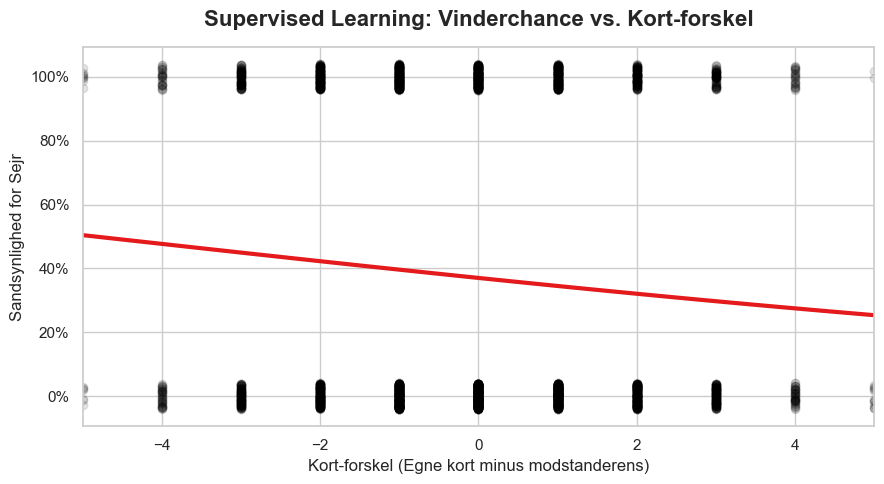

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Vi starter med en frisk kopi af dataen, for at sikre os at vi har alle kolonner
cardsdf = pd.read_csv('data/cleaneddf.csv')

if 'Total Cards' not in cardsdf.columns:
    cardsdf['Total Cards'] = cardsdf['YELLOWCARDS'] + cardsdf['REDCARDS']

# Klargører target (Vinder) og feature (Kort-forskel)
def klargor_regression(kamp):
    if len(kamp) == 2:
        maal = kamp['GOALS'].values
        if maal[0] > maal[1]:
            kamp['Vandt'] = [1, 0]
        elif maal[0] < maal[1]:
            kamp['Vandt'] = [0, 1]
        else:
            kamp['Vandt'] = [0, 0]
            
        # Find kort-forskel (Vores kort minus modstanderens kort)
        kort = kamp['Total Cards'].values
        kamp['Card_Diff'] = [kort[0] - kort[1], kort[1] - kort[0]]
    else:
        kamp['Vandt'] = np.nan
        kamp['Card_Diff'] = np.nan
    return kamp

# Vi anvender funktionen og fjerner de rækker, hvor vi mangler data
cardsdf = cardsdf.groupby('MATCH_WYID', group_keys=False).apply(klargor_regression).dropna(subset=['Vandt', 'Card_Diff'])

# Sørger for at datatyperne er er i den rigtige datatype (float/int), til beregningerne
cardsdf['Card_Diff'] = cardsdf['Card_Diff'].astype(float)
cardsdf['Vandt'] = cardsdf['Vandt'].astype(int)


# Definerer "X" (input/årsag) og "Y" (output/virkning)
X = cardsdf[['Card_Diff']]
y = cardsdf['Vandt']

# Splitter data i træning (80%) og test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Opretter og træner den logistiske regressionsmodel
# Modellen lærer sammenhængen mellem kort og vinderchancer
model = LogisticRegression()
model.fit(X_train, y_train)

# Udskriver modellens matematiske fund
print("--- BEVIS FRA SUPERVISED LEARNING ---")
print(f"Modellens korrelation for Kort-forskel: {model.coef_[0][0]:.4f}")
print("(Et negativt tal beviser, at hvis du får FLERE kort end modstanderen, falder chancen for at vinde)\n")

# Visualisering af sandsynligheden (Sandsynlighed for sejr vs. Kort-forskel)
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Regplot med logistic=True tegner en S-kurve (Sigmoid), vores plot ligner ikke et S, men det er en del af en Sigmoid 
sns.regplot(
    data=cardsdf, 
    x='Card_Diff', 
    y='Vandt', 
    logistic=True, 
    ci=None,
    y_jitter=0.04, # 
    scatter_kws={'alpha': 0.1, 'color': 'black'}, 
    line_kws={'color': '#e41a1c', 'linewidth': 3}
)

# Formattering af titler og akser
plt.title('Supervised Learning: Vinderchance vs. Kort-forskel', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Kort-forskel (Egne kort minus modstanderens)', fontsize=12)
plt.ylabel('Sandsynlighed for Sejr', fontsize=12)

# Gør Y-aksen til pæne procenter
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Vi zoomer ind på den mest relevante del af x-aksen
plt.xlim(-5, 5) 

plt.tight_layout()
plt.show()

#### Konklusion
Hypotese 1: Korrelation mellem kort og resultat
* Hypotesen bekræftes. Vores logistiske regressionsmodel viser en tydelig negativ korrelation (koefficient: -0.1610), hvilket betyder, at sandsynligheden for en sejr falder proportionelt med antallet af modtagne kort. Som det ses i vores "Stacked Bar Chart", har de grove kampe (Cluster: Grov kamp) den laveste sejrsprocent. Det mest interessante fund er dog, at det ikke nødvendigvis er "Fairplay", der vinder mest, men derimod evnen til at balancere på grænsen. Regressionsplottet afslører, at vinderchancen falder fra ca. 40% til under 30%, når et hold modtager 2-3 kort mere end modstanderen.

Hypotese 2: Man vinder flere kampe, jo flere frispark et hold får dømt til deres fordel
* Hypotesen bekræftes delvist, men med en vigtig nuancering: Det er ikke antallet af frispark i sig selv, der skaber sejren, men frisparkenes effektivitet (evnen til at begå frispark uden at modtage kort). Vores Cluster-analyse identificerer en "Taktisk" spillestil (Mange frispark, få kort). Data viser, at hold i denne kategori har en højere sejrsrate end de hold, der spiller "Fairplay". Dette indikerer, at taktiske frispark er et effektivt værktøj til at bryde modstanderens rytme og forsvare en føring, så længe man undgår de kampafgørende disciplinære straffe (kort). "Grov kamp"-clusteret beviser, at når frisparkene kammer over og bliver til kort, forsvinder den taktiske fordel og bliver til en statistisk ulempe.

### Hypotese 3: Mængden af hjørnespark har en korrelation til at vinde kampe

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Vi starter med at rydde op i kolonnerne for at undgå fejl, hvis koden køres flere gange
cols_to_drop = ['OPPONENT_TEAM_WYID', 'OPPONENT_GOALS', 'WIN']
df_safe = cleaneddf.drop(columns=[col for col in cols_to_drop if col in cleaneddf.columns])

# For at vide om et hold vandt, skal vi kende modstanderens mål. 
# Vi laver en kopi af dataen, kalder det "opponent data", og fletter det sammen med originalen.
opp_df = df_safe[['MATCH_WYID', 'TEAM_WYID', 'GOALS']].copy()
opp_df.columns = ['MATCH_WYID', 'OPPONENT_TEAM_WYID', 'OPPONENT_GOALS']
df_merged = pd.merge(df_safe, opp_df, on='MATCH_WYID')

# Vi fjerner de rækker, hvor et hold er matchet mod sig selv (fejl i merge)
df_merged = df_merged[df_merged['TEAM_WYID'] != df_merged['OPPONENT_TEAM_WYID']]

# Her skaber vi vores 'Target' (mål): 1 hvis holdet scorede flere mål end modstanderen, ellers 0.
df_merged['WIN'] = (df_merged['GOALS'] > df_merged['OPPONENT_GOALS']).astype(int)

#### Opsætning af Random Forest Modellen

In [70]:
# Vi vælger de statistikker (Features), som maskinen skal lære fra
features = ['CORNERS', 'XG', 'TOUCHESINBOX', 'SHOTS']
X = df_merged[features]
y = df_merged['WIN']

# Vi splitter dataen: 80% til træning og 20% til test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vi træner en "Skov" af 100 beslutningstræer (Random Forest). 
# max_depth=5 sikrer, at træerne ikke bliver for komplekse og "overfitter".
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Maskinen kommer med sit bedste gæt på test-sættet
y_pred = rf_model.predict(X_test)

#### Evaluering (Confusion Matrix)

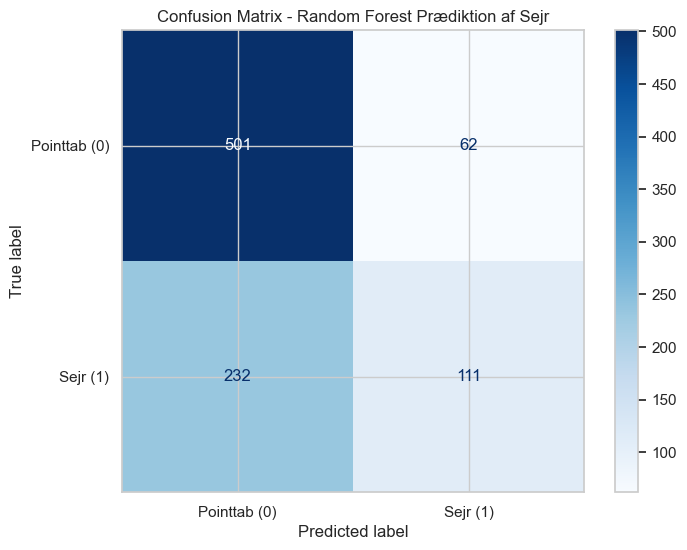

In [71]:
# En Confusion Matrix viser os præcis, hvor maskinen gættede rigtigt og forkert
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pointtab (0)', 'Sejr (1)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Random Forest Prædiktion af Sejr')
plt.show()

#### FEATURE IMPORTANCE

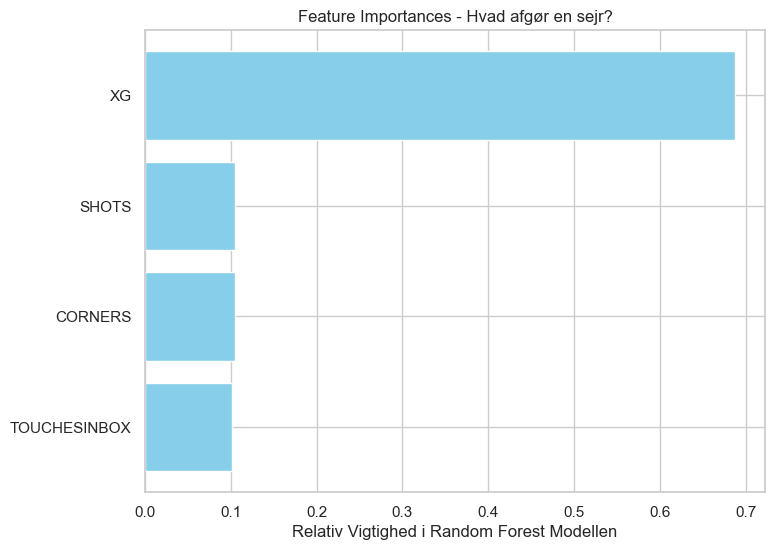

In [72]:
# Her trækker vi vigtigheden ud: Hvilke features brugte maskinen mest til at afgøre kampen?
importances = rf_model.feature_importances_
indices = np.argsort(importances) # Sorterer dem, så den vigtigste faktor er øverst


fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Feature Importances - Hvad afgør en sejr?')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relativ Vigtighed i Random Forest Modellen')
plt.show()

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import warnings
warnings.filterwarnings('ignore')

### Datapreperation (Genskabelse af modstander data)

# Vi fjerner gamle kolonner for at starte på en frisk
cols_to_drop = ['OPPONENT_TEAM_WYID', 'OPPONENT_GOALS', 'WIN']
df_safe = cleaneddf.drop(columns=[col for col in cols_to_drop if col in cleaneddf.columns])

# For at kunne analysere sejre, fletter vi data så hvert hold matches med deres modstander
opp_df = df_safe[['MATCH_WYID', 'TEAM_WYID', 'GOALS']].copy()
opp_df.columns = ['MATCH_WYID', 'OPPONENT_TEAM_WYID', 'OPPONENT_GOALS']
df_merged = pd.merge(df_safe, opp_df, on='MATCH_WYID')

# Vi fjerner rækker hvor holdet matches med sig selv
df_merged = df_merged[df_merged['TEAM_WYID'] != df_merged['OPPONENT_TEAM_WYID']]

# Vi skaber WIN-kolonnen (1 for sejr, 0 for andet)
df_merged['WIN'] = (df_merged['GOALS'] > df_merged['OPPONENT_GOALS']).astype(int)

#### Clustering (Unsupervised Learning)

In [74]:
cluster_features = ['CORNERS', 'XG']
df_merged = df_merged.dropna(subset=cluster_features)
X_cluster = df_merged[cluster_features]

# Vi vælger de to features, der skal definere de taktiske profiler
kmeans = KMeans(n_clusters=3, random_state=42)
df_merged['Cluster'] = kmeans.fit_predict(X_cluster)

#### Dynamisk Navngivning og Plotting

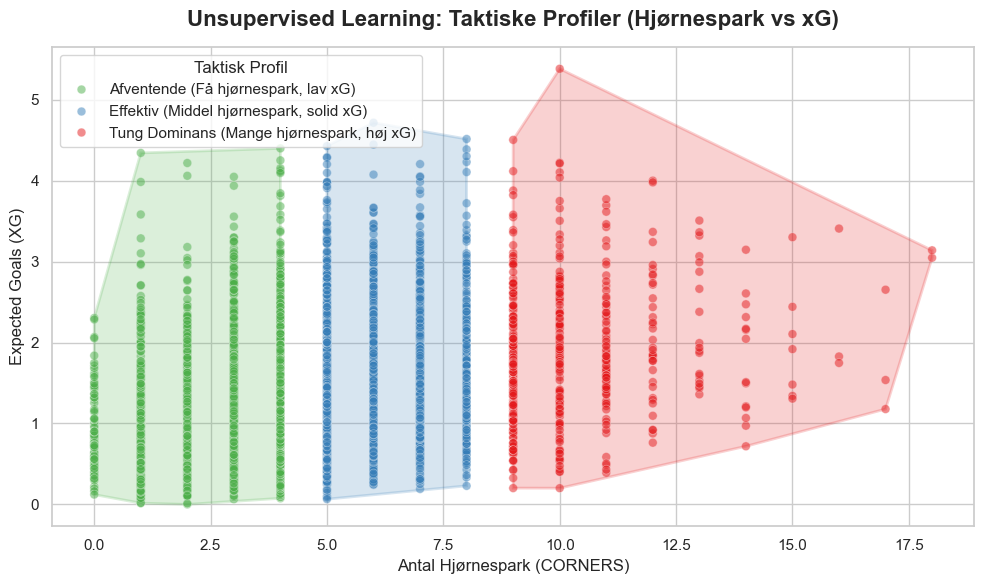

In [75]:
# For at sikre at farverne altid passer til spillestilen (selvom gruppenumre skifter),
# sorterer vi grupperne efter gennemsnitligt antal hjørnespark.
centroids = df_merged.groupby('Cluster')['CORNERS'].mean().sort_values()

# Vi tildeler logiske navne baseret på hvor meget pres holdene lægger
cluster_mapping = {
    centroids.index[0]: 'Afventende (Få hjørnespark, lav xG)',
    centroids.index[1]: 'Effektiv (Middel hjørnespark, solid xG)',
    centroids.index[2]: 'Tung Dominans (Mange hjørnespark, høj xG)'
}
df_merged['Taktisk Profil'] = df_merged['Cluster'].map(cluster_mapping)


# Definerer vores faste farvetema
farver = {
    'Afventende (Få hjørnespark, lav xG)': '#4daf4a', # Grøn (Passiv)
    'Effektiv (Middel hjørnespark, solid xG)': '#377eb8', # Blå (Balanceret)
    'Tung Dominans (Mange hjørnespark, høj xG)': '#e41a1c' # Rød (Aggressiv)
}

plt.figure(figsize=(10, 6))

# Tegner alle de enkelte kampe som små prikker
sns.scatterplot(
    data=df_merged,
    x='CORNERS',
    y='XG',
    hue='Taktisk Profil',
    palette=farver,
    alpha=0.5,
    s=40
)

# Tegner polygoner (ConvexHull) som "skaller" omkring hver taktisk profil
for gruppe_navn in df_merged['Taktisk Profil'].unique():
    # Udtrækker x og y koordinater for den specifikke gruppe
    prikker = df_merged[df_merged['Taktisk Profil'] == gruppe_navn][['CORNERS', 'XG']].values
    
    # Der kræves mindst 3 punkter for at tegne en 2D polygon
    if len(prikker) >= 3:
        hull = ConvexHull(prikker)
        plt.fill(
            prikker[hull.vertices, 0],
            prikker[hull.vertices, 1],
            alpha=0.2,
            color=farver[gruppe_navn],
            edgecolor=farver[gruppe_navn],
            lw=2
        )

# Slutfinish med titler og labels
plt.title('Unsupervised Learning: Taktiske Profiler (Hjørnespark vs xG)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Antal Hjørnespark (CORNERS)', fontsize=12)
plt.ylabel('Expected Goals (XG)', fontsize=12)
plt.legend(title='Taktisk Profil', loc='upper left')

plt.tight_layout()
plt.show()

#### Konklusion
Hypotese 3: Mængden af hjørnespark har en korrelation til at vinde kampe
* Hypotesen afvises. Mængden af hjørnespark har ikke en stærk, isoleret korrelation til at vinde fodboldkampe.
Vores Machine Learning-modeller beviser dette på to fronter:

* Supervised Learning (Random Forest): Modellen viser, at hjørnespark har en meget lav "Feature Importance". For at gætte kampens vinder kigger algoritmen næsten udelukkende på chancekvalitet (xG) og antal skud, mens den stort set ignorerer antallet af hjørnespark.

* Unsupervised Learning (K-Means Clustering): Vores klyngeanalyse samlede holdene i taktiske profiler. Her så vi direkte, at gruppen med absolut flest hjørnespark ("Tung Dominans") ironisk nok var den klynge med den laveste vinderprocent.

* Sammenfatning:
Hjørnespark fører ikke automatisk til sejr. Rigtig mange hjørnespark indikerer ofte blot, at et hold stanger mod et kompakt forsvar uden at kunne omsætte overtaget til farlige chancer. Kvalitet (xG) slår kvantitet (hjørnespark).

---

# **Samlet afsluttende konklusion**

* Denne opgave har med både statistiske analyser og machine learning undersøgt, hvilke faktorer der har størst betydning for udfaldet af fodboldkampe. På tværs af analyserne ses det tydeligt, at de mest afgørende variable er relateret til produktion af chancer og offensiv kvalitet, såsom xG, skud og effektivitet foran mål. Desuden viser analysen, at holdets disciplin spiller en væsentlig rolle, da flere disciplinære sanktioner i form af kort mindsker vinderchancerne. Samtidig viser resultaterne, at faktorer som vejr og antallet hjørnespark ikke i sig selv har en stærk eller afgørende effekt på kampens udfald.


* Vores analyser peger derfor på, at det ikke er de ydre forhold alene, men derimod holdenes evne til at skabe og udnytte chancer, der bedst forklarer forskellen mellem sejr og nederlag. De supervised learning-modeller, vi anvendte, viste især, at nogle variable har langt større forklaringskraft end andre, mens de unsupervised modeller gav et visuelt og taktisk overblik over forskellige mønstre i dataen. Dette gjorde det muligt både at teste konkrete hypoteser og samtidig opdage underliggende strukturer i kampdataen.

* Samlet set viser opgaven, at machine learning er et nyttigt redskab til at analysere sportsdata, fordi metoderne både kan bruges til forudsigelse, forklaring og mønstergenkendelse. Resultaterne understreger samtidig, at fodbold er et komplekst spil, hvor enkelte variable sjældent kan stå alene, men hvor flere faktorer tilsammen skaber det samlede kampbillede.